In [10]:
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from adjustText import adjust_text
from scipy.stats import binom, false_discovery_control
from matplotlib.collections import PathCollection
import seaborn as sns

In [11]:
def load_arial(arial_folder_path):
    from pathlib import Path
    from matplotlib import font_manager, rcParams
    for font_path in Path(arial_folder_path).glob('*.TTF'):
        font_manager.fontManager.addfont(str(font_path))

    arial_n = {'fontproperties':font_manager.FontProperties(fname="misc/arial/ARIALN.TTF")}
    arial_nb = {'fontproperties':font_manager.FontProperties(fname="misc/arial/ARIALNB.TTF")}

    assert 'Arial' in [f.name for f in font_manager.fontManager.ttflist]

    rcParams['font.family'] = 'sans-serif'
    rcParams['font.sans-serif'] = ['Arial']
    rcParams['ps.fonttype'] = 42
    rcParams['pdf.fonttype'] = 42

    rcParams['mathtext.fontset'] = 'custom'
    rcParams['mathtext.rm'] = 'Arial'
    rcParams['mathtext.it'] = 'Arial:italic'
    rcParams['mathtext.bf'] = 'Arial:bold'

    return arial_n, arial_nb
load_arial('/stor/home/tms4478/work/Arial')

({'fontproperties': <matplotlib.font_manager.FontProperties at 0x70cc15b1f010>},
 {'fontproperties': <matplotlib.font_manager.FontProperties at 0x70d01c1ccc70>})

# HK 177

In [12]:
ad_hk177 = sc.read_h5ad('HK177_02_processed.h5ad')
ad_hk177 = ad_hk177[:, np.mean(ad_hk177.X != 0., axis=0) > 0.1]

In [13]:
ad_hk177.layers

LayersView with keys: norm_counts, raw_counts

In [14]:
ad_hk177.obs['sample_name'] = ad_hk177.obs['sample'].map({
    'SoftMi':'Soft Migratory',
    'SoftNon': 'Soft Non-Migratory',
    'StiffMi': 'Stiff Migratory',
    'StiffNon':'Stiff Non-Migratory'
    })

/tmp/ipykernel_491669/385206994.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  ad_hk177.obs['sample_name'] = ad_hk177.obs['sample'].map({


In [15]:
geneFileLoc = 'Macosko_cell_cycle_genes.txt'
cc_genes = pd.read_table(geneFileLoc, delimiter='\t')
s_genes = cc_genes['S'].dropna()
g2m_genes = cc_genes['G2.M'].dropna()

s_genes_mm = [gene.lower() for gene in s_genes]
g2m_genes_mm = [gene.lower() for gene in g2m_genes]

def cc_regress(adata):
    s_genes_mm_ens = adata.var_names[np.in1d([i.lower() for i in adata.var_names], s_genes_mm)]
    g2m_genes_mm_ens = adata.var_names[np.in1d([i.lower() for i in adata.var_names], g2m_genes_mm)]

    sc.tl.score_genes_cell_cycle(adata, s_genes=s_genes_mm_ens, g2m_genes=g2m_genes_mm_ens)
    adata.obs['cc_difference'] = adata.obs['S_score'] - adata.obs['G2M_score']
    sc.pp.regress_out(adata, 'cc_difference')
    adata.uns['Processing'] = ['QC','Normalized','Cell Cycle Regressed']

    return adata

In [16]:
ad_hk177 = cc_regress(ad_hk177)
ad_hk177.layers['cc_regressed'] = ad_hk177.X.copy()
ad_hk177.X = ad_hk177.layers['norm_counts'].copy()

/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.

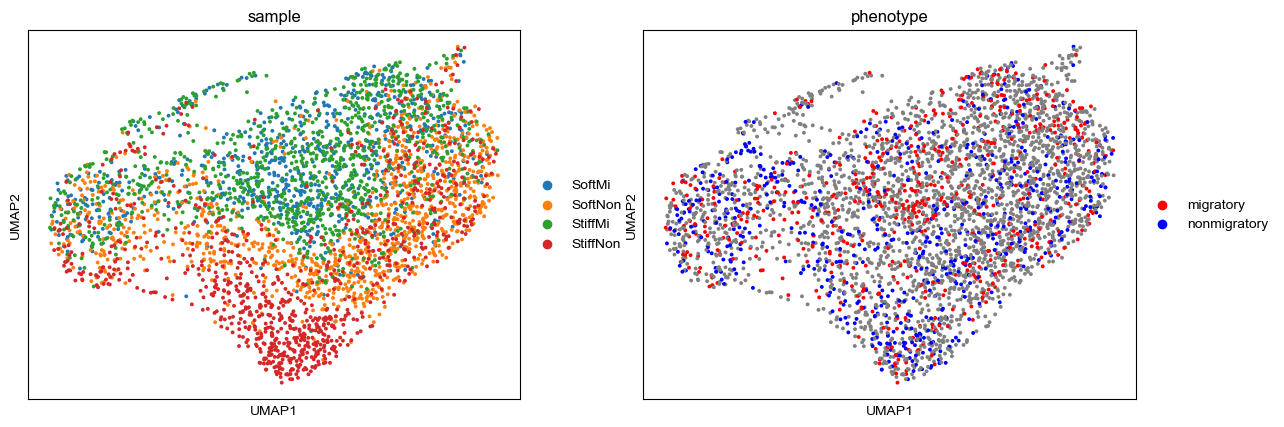

In [17]:
sc.pl.umap(
    ad_hk177,
    color=['sample', 'phenotype'],
    layer ='cc_regressed',
)

In [18]:
ad_hk177.uns['sample_colors']=['#440154ff','#22a884ff','#b22222','#4169e1']

/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


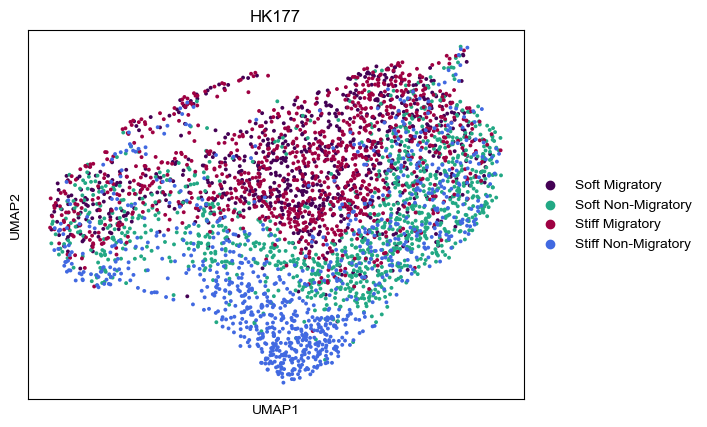

In [19]:
sc.pl.umap(
    ad_hk177,
    color='sample_name',
    palette =['#440154ff','#22a884ff','#9e0142','#4169e1'],
    layer ='cc_regressed',
    title='HK177',
    frameon =True,
    legend_loc='right margin',
    #save ='HK177_UMAP.svg'
)

From this dendrogram we can see that cells are much more differentiated by the fact that they migrated through the gel, rather than the stiffness of their substrate.

/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/tools/_dendrogram.py:135: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = rep_df.groupby(level=0).mean()


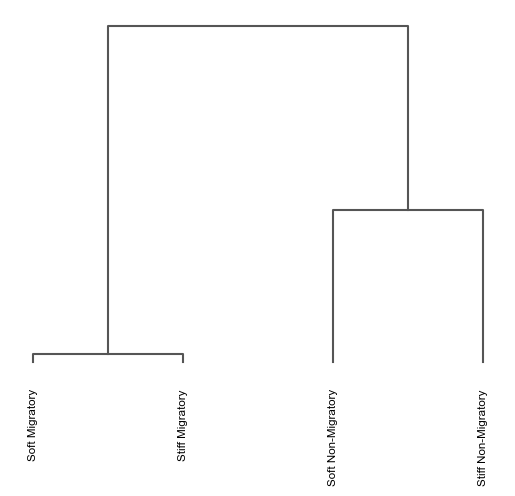

<Axes: >

In [20]:
sc.pl.dendrogram(ad_hk177, groupby='sample_name')

We add two new `obs` - one for `substrate` that says if the cells came from/are in a stiff gel (StiffMi and StiffNon vs. SoftMi and SoftNon), and one for `gel_side` that says if cells migrated through the gel - `'bottom'`, or if cells stayed in the top gel - `'top'` (StiffMi and SoftMi vs StiffNon and SoftNon).

In [21]:
ad_hk177.obs['substrate'] = ['soft' if c.startswith('Soft') else 'stiff' for c in ad_hk177.obs['sample']]
ad_hk177.obs['gel_side'] = ['bottom' if c.endswith('Mi') else 'top' for c in ad_hk177.obs['sample']]
ad_hk177.obs['substrate']

AAACCCACACGTAACT-1     soft
AAACGCTAGCACTAGG-1     soft
AAACGCTCATTGGCAT-1     soft
AAACGCTGTAATGATG-1     soft
AAACGCTTCACATACG-1     soft
                      ...  
TTTCGATTCCGGCTTT-4    stiff
TTTGGTTAGAATTGCA-4    stiff
TTTGGTTAGCGTCTCG-4    stiff
TTTGGTTCAGCATGCC-4    stiff
TTTGTTGGTACTCGTA-4    stiff
Name: substrate, Length: 3850, dtype: object

/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.

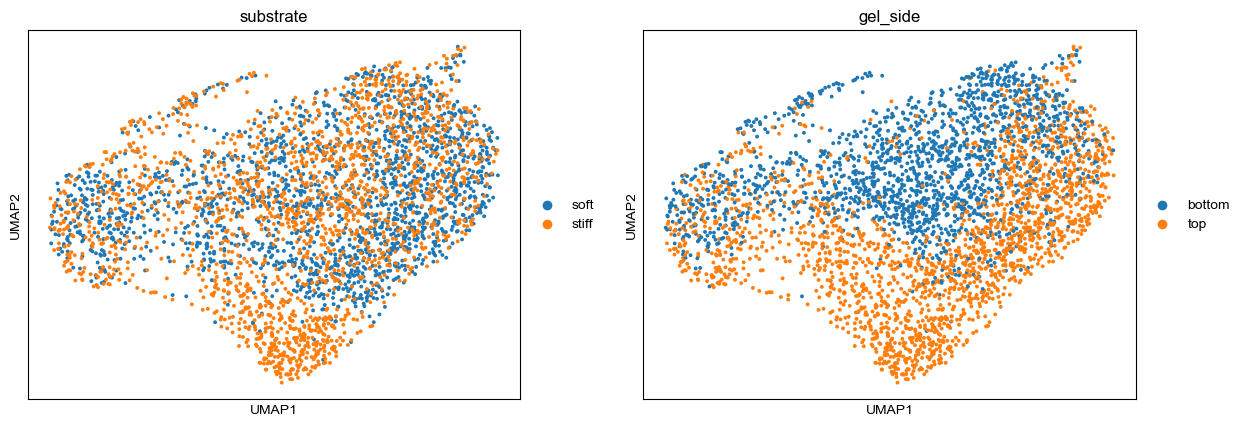

In [22]:
sc.pl.umap(
    ad_hk177,
    color=['substrate', 'gel_side']
)

In [23]:
p_cutoff = 0.0005
lfc_cutoff = 0.2

In [24]:
ad_hk177_sub = ad_hk177[ad_hk177.obs['lineage'] != 'none']

## Stiff vs. Soft

In [26]:
stiff_vs_soft_hk177 = pd.read_csv('mast_hk177/stiff_vs_soft.csv', index_col=0)
stiff_vs_soft_hk177.loc[(stiff_vs_soft_hk177['FDR'] < p_cutoff) & (np.abs(stiff_vs_soft_hk177['coef']) > lfc_cutoff), :].sort_values('coef')

,Pr(>Chisq),coef,FDR
primerid,,,
MT1X,5.294161e-29,-0.584561,3.668854e-26
TMEM158,8.750299e-13,-0.376928,8.958118e-11
PLIN2,1.821132e-13,-0.376674,2.343797e-11
SERPINE1,3.061077e-12,-0.374806,2.799847e-10
ANGPTL4,8.331052e-16,-0.372411,1.389897e-13
...,...,...,...
FILIP1L,6.484857e-29,0.417613,4.173005e-26
FSTL1,3.581015e-36,0.428576,4.608766e-33
MT-CO2,2.310799e-18,0.447846,5.204497e-16


In [27]:
p_cutoff = 0.00005
lfc_cutoff = 0.6

stiffnon_vs_softnon_hk177 = pd.read_csv('mast_hk177/stiffnon_vs_softnon.csv', index_col=0)
stiffnon_vs_softnon_hk177=stiffnon_vs_softnon_hk177.loc[~stiffnon_vs_softnon_hk177.index.str.startswith(('RPL','RPS'))]
stiffnon_vs_softnon_hk177.loc[(stiffnon_vs_softnon_hk177['FDR'] < p_cutoff) & (np.abs(stiffnon_vs_softnon_hk177['coef']) > lfc_cutoff), :].sort_values('coef')

,Pr(>Chisq),coef,FDR
primerid,,,
MT1X,2.507335e-49,-1.189131,2.823572e-46
TMEM158,1.097408e-24,-0.765519,1.938539e-22
STC1,7.222448e-33,-0.756620,2.502578e-30
ANGPTL4,2.272172e-29,-0.665777,5.848570e-27
SERPINE1,5.515850e-21,-0.655658,6.807163e-19
SLAMF9,6.744849e-34,-0.636274,2.641928e-31
TIMP2,1.301730e-35,0.607407,6.172257e-33
MT-CO3,8.887986e-21,0.630078,1.067625e-18
TGFBI,4.491649e-41,0.647017,2.890376e-38


Text(0, 0.5, '')

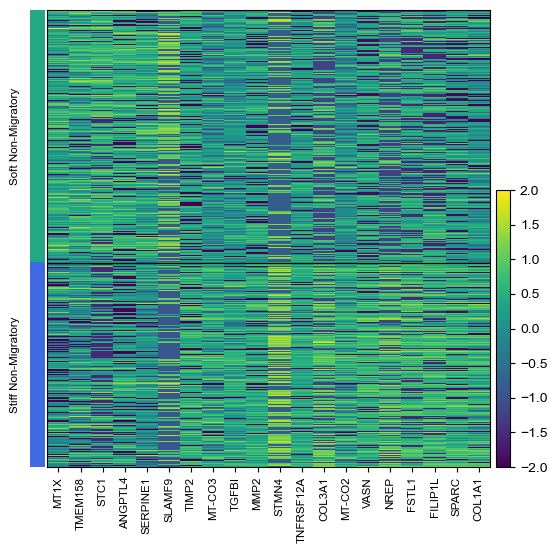

In [28]:
p_cutoff = 0.00005
lfc_cutoff = 0.6

axs = sc.pl.heatmap(
    sc.pp.scale(ad_hk177[np.logical_or(ad_hk177.obs['sample'] == 'StiffNon', ad_hk177.obs['sample'] == 'SoftNon')], copy=True),
    var_names=stiffnon_vs_softnon_hk177.loc[(stiffnon_vs_softnon_hk177['FDR'] < p_cutoff) & (np.abs(stiffnon_vs_softnon_hk177['coef']) > lfc_cutoff), :].sort_values('coef').index,
    groupby='sample_name',
    vmax=2, vmin=-2,
    cmap='viridis',
    swap_axes=False,
    show = False
    #dendrogram=True
)
axs['groupby_ax'].set_yticks(axs['groupby_ax'].get_yticks(), axs['groupby_ax'].get_yticklabels(), rotation=90, ha='right', va='center')
axs['groupby_ax'].set_ylabel('')
#plt.savefig('stiffnon_v_softnon_hk177_heatmap.svg',  bbox_inches='tight')


/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be igno

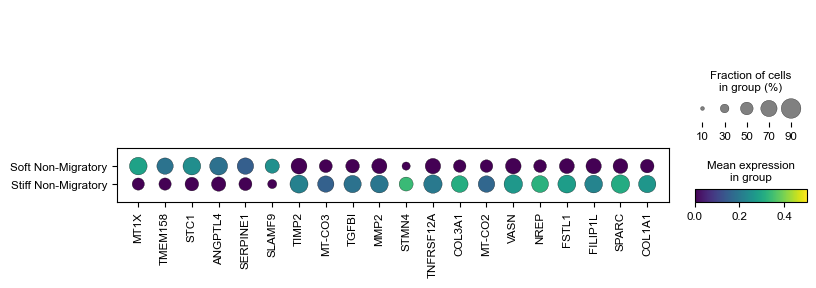

In [30]:
p_cutoff = 0.00005
lfc_cutoff = 0.6

sc.pl.dotplot(
    sc.pp.scale(ad_hk177[np.logical_or(ad_hk177.obs['sample'] == 'StiffNon', ad_hk177.obs['sample'] == 'SoftNon')], copy=True),
    #ad_hk177[np.logical_or(ad_hk177.obs['sample'] == 'StiffNon', ad_hk177.obs['sample'] == 'SoftNon')],
    var_names=stiffnon_vs_softnon_hk177.loc[(stiffnon_vs_softnon_hk177['FDR'] < p_cutoff) & (np.abs(stiffnon_vs_softnon_hk177['coef']) > lfc_cutoff), :].sort_values('coef').index,
    groupby='sample_name',
    vmax=0.5, vmin=0,
    cmap='viridis',
    swap_axes=False,
    dendrogram=True
)

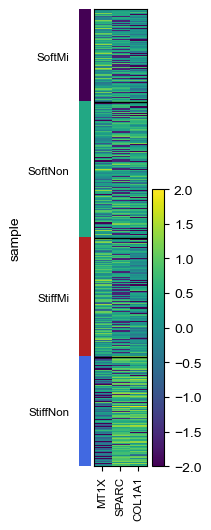

In [31]:
p_cutoff = 0.0005
lfc_cutoff = 0.5

sc.pl.heatmap(
    sc.pp.scale(ad_hk177, copy=True),
    var_names=stiff_vs_soft_hk177.loc[(stiff_vs_soft_hk177['FDR'] < p_cutoff) & (np.abs(stiff_vs_soft_hk177['coef']) > lfc_cutoff), :].sort_values('coef').index,
    groupby='sample',
    vmax=2, vmin=-2 
    #dendrogram=True
)

In [32]:
p_cutoff = 0.0005
lfc_cutoff = 0.2

stiffmi_vs_softmi_hk177 = pd.read_csv('mast_hk177/stiffmi_vs_softmi.csv', index_col=0)
stiffmi_vs_softmi_hk177.loc[(stiffmi_vs_softmi_hk177['FDR'] < p_cutoff) & (np.abs(stiffmi_vs_softmi_hk177['coef']) > lfc_cutoff), :].sort_values('coef')

,Pr(>Chisq),coef,FDR
primerid,,,


## Top vs. bottom

In [33]:
p_cutoff = 0.0005
lfc_cutoff = 0.7
top_vs_bottom_hk177 = pd.read_csv('mast_hk177/top_vs_bottom.csv', index_col=0)
top_vs_bottom_hk177.loc[(top_vs_bottom_hk177['FDR'] < p_cutoff) & (np.abs(top_vs_bottom_hk177['coef']) > lfc_cutoff), :].sort_values('coef')

,Pr(>Chisq),coef,FDR
primerid,,,
COL1A1,5.372928e-127,-1.195620,2.420236e-123
TGFBI,4.552086e-120,-0.892735,1.366991e-116
SPARC,1.237861e-104,-0.881611,2.230377e-101
DCN,2.779175e-76,-0.816218,1.745214e-73
IL11,5.748034e-73,-0.802765,2.725476e-70
TNFRSF12A,9.026713e-75,-0.778367,4.783627e-72
FSTL1,2.776264e-107,-0.759845,6.252841e-104
CRYAB,1.446189e-91,-0.740290,1.861245e-88
IER3,2.062620e-46,-0.718557,3.643557e-44


In [34]:
stiffmi_vs_stiffnon_hk177 = pd.read_csv('mast_hk177/stiffmi_vs_stiffnon.csv', index_col=0)
stiffmi_vs_stiffnon_hk177.loc[(stiffmi_vs_stiffnon_hk177['FDR'] < p_cutoff) & (np.abs(stiffmi_vs_stiffnon_hk177['coef']) > lfc_cutoff), :].sort_values('coef')

,Pr(>Chisq),coef,FDR
primerid,,,
COL1A1,3.368042e-119,-1.793847,1.516966e-115
SPARC,2.578328e-103,-1.384475,5.806395e-100
TGFBI,7.515358e-111,-1.215947,2.256611e-107
TNFRSF12A,6.601938e-77,-1.139272,7.433782e-74
FSTL1,4.727564e-97,-1.132479,8.166480e-94
DCN,2.721328e-57,-1.031906,1.225686e-54
NREP,2.414143e-81,-0.983885,3.106657e-78
FILIP1L,1.423935e-55,-0.967621,5.830368e-53
COL3A1,7.019450e-59,-0.907153,3.512845e-56


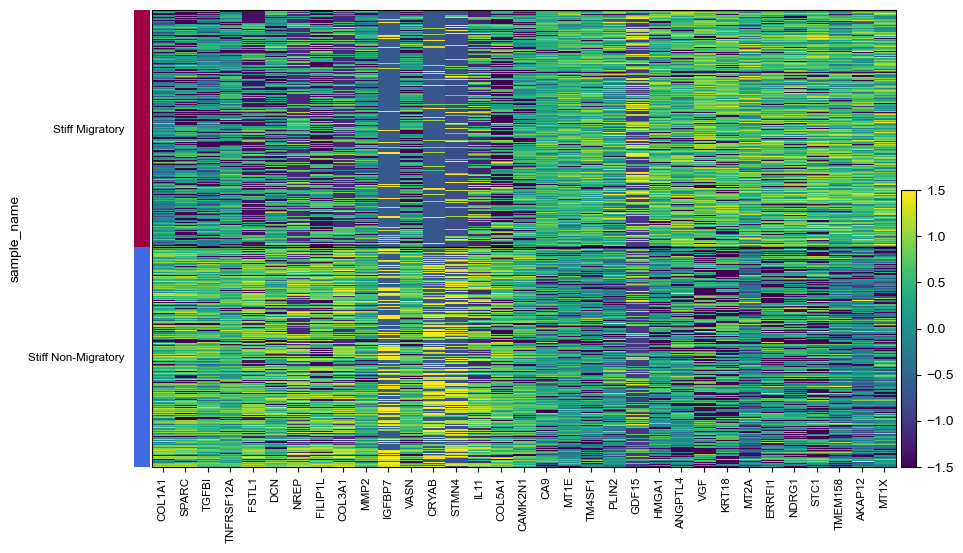

In [35]:
p_cutoff = 0.00005
lfc_cutoff = .75

sc.pl.heatmap(
    sc.pp.scale(ad_hk177[np.logical_or(ad_hk177.obs['sample'] == 'StiffMi', ad_hk177.obs['sample'] == 'StiffNon')], copy=True),
    var_names=stiffmi_vs_stiffnon_hk177.loc[(stiffmi_vs_stiffnon_hk177['FDR'] < p_cutoff) & (np.abs(stiffmi_vs_stiffnon_hk177['coef']) > lfc_cutoff), :].sort_values('coef').index,
    groupby='sample_name',
    vmax=1.5, vmin=-1.5
    #dendrogram=True
)

In [36]:
softmi_vs_softnon_hk177 = pd.read_csv('mast_hk177/softmi_vs_softnon.csv', index_col=0)
softmi_vs_softnon_hk177.loc[(softmi_vs_softnon_hk177['FDR'] < p_cutoff) & (np.abs(softmi_vs_softnon_hk177['coef']) > 0.5), :].sort_values('coef')

,Pr(>Chisq),coef,FDR
primerid,,,
IL11,3.927846e-40,-0.823168,7.072479e-37
IER3,5.661078e-28,-0.784455,3.640477e-25
CRYAB,1.580807e-40,-0.689214,4.286852e-37
PPP1R15A,2.905505e-44,-0.658380,1.307913e-40
COL1A1,2.043048e-23,-0.624764,7.663986e-21
HTRA1,1.420815e-21,-0.580403,4.737630e-19
TGFBI,2.256395e-25,-0.573434,1.128573e-22
DCN,2.638128e-20,-0.562996,6.786018e-18
MEG3,3.296396e-20,-0.518941,8.020933e-18


In [37]:
top_vs_bottom_hk177_heatmap = top_vs_bottom_hk177.loc[(top_vs_bottom_hk177['FDR'] < 0.000005) & (np.abs(top_vs_bottom_hk177['coef']) >=0.75), :].sort_values('coef').index 

Text(0, 0.5, '')

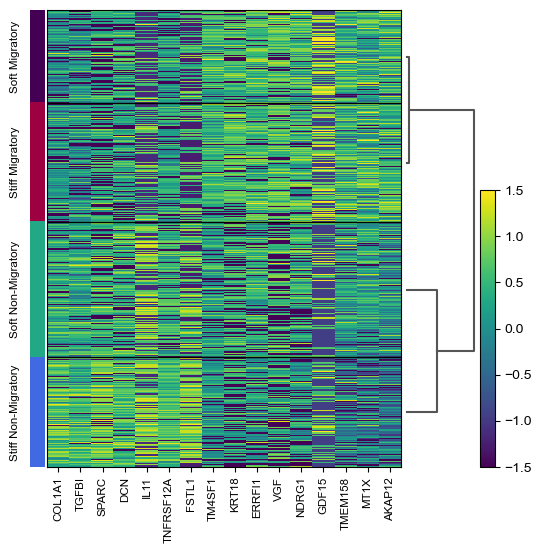

In [38]:
axs = sc.pl.heatmap(
    sc.pp.scale(ad_hk177, copy=True),
    var_names=top_vs_bottom_hk177_heatmap,
    groupby='sample_name',
    vmax=1.5, vmin=-1.5,
    dendrogram=True,
    show=False
)
axs['groupby_ax'].set_yticks(axs['groupby_ax'].get_yticks(), axs['groupby_ax'].get_yticklabels(), rotation=90, ha='right', va='center')
axs['groupby_ax'].set_ylabel('')
#plt.savefig('figures/top_v_bottom_hk177_heatmap.svg')


In [39]:
lfc_cutoff =0.5
p_cutoff =0.000005

mi_sig = top_vs_bottom_hk177.loc[(top_vs_bottom_hk177['FDR'] < p_cutoff) & (np.abs(top_vs_bottom_hk177['coef']) > 0.5)]
softmi_sig = softmi_vs_softnon_hk177.loc[(softmi_vs_softnon_hk177['FDR'] < p_cutoff) & (np.abs(softmi_vs_softnon_hk177['coef']) > 0.4), :]

stiffness_independent_mi = softmi_sig.loc[~softmi_sig.index.isin(mi_sig.index)].copy()
stiffness_independent_mi.sort_values('coef')

,Pr(>Chisq),coef,FDR
primerid,,,
IGFBP4,1.586870e-18,-0.517186,3.174798e-16
APOE,1.408787e-10,-0.497107,7.594795e-09
UBE2S,1.491200e-13,-0.476899,1.398466e-11
PMEPA1,6.121638e-25,-0.467041,2.624433e-22
EIF5,4.637742e-27,-0.463195,2.783573e-24
JUN,6.131868e-16,-0.463082,8.904066e-14
TXNIP,4.305740e-11,-0.460941,2.517180e-09
SERTAD1,2.468490e-21,-0.451078,7.663383e-19
FUS,5.784791e-25,-0.431126,2.604024e-22


In [40]:
stiffmi_vs_stiffnon_hk177.loc[(stiffmi_vs_stiffnon_hk177['FDR'] < p_cutoff) & (np.abs(stiffmi_vs_stiffnon_hk177['coef']) > lfc_cutoff) & (softmi_vs_softnon_hk177['FDR'] >= p_cutoff), :].sort_values('coef')

,Pr(>Chisq),coef,FDR
primerid,,,
FILIP1L,1.423935e-55,-0.967621,5.830368e-53
COL3A1,7.019450e-59,-0.907153,3.512845e-56
VASN,1.847018e-60,-0.837513,1.039871e-57
STMN4,2.524549e-59,-0.799021,1.337714e-56
FN1,8.536518e-30,-0.748047,8.544107e-28
HLA-B,9.707329e-36,-0.655074,1.433502e-33
COL6A2,1.050054e-32,-0.642454,1.278228e-30
MFAP4,3.409932e-23,-0.619438,2.275308e-21
TNC,6.875862e-36,-0.619185,1.067892e-33


In [41]:
ad_hk177[np.logical_or(ad_hk177.obs['sample'] == 'StiffMi', ad_hk177.obs['sample'] == 'StiffNon')]

View of AnnData object with n_obs × n_vars = 1921 × 8873
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'doublet_score', 'predicted_doublets', 'lineage', 'S_score', 'G2M_score', 'phase', 'cc_difference', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'phenotype', 'sample_name', 'substrate', 'gel_side'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Processing', 'dendrogram_sample', 'hvg', 'leiden', 'leiden_res0_25_colors', 'leiden_res0_5_colors', 'leiden_res1_colors', 'log1p', 'nei

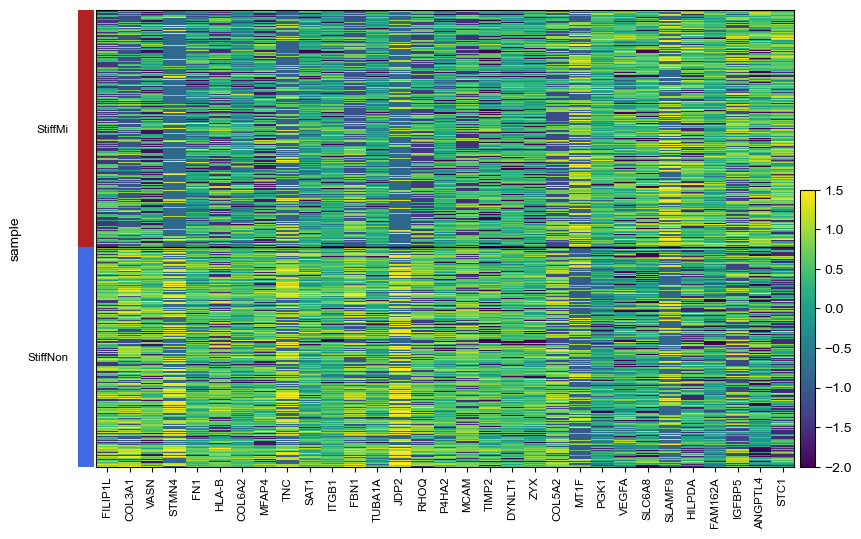

In [42]:
sc.pl.heatmap(
    sc.pp.scale(ad_hk177[np.logical_or(ad_hk177.obs['sample'] == 'StiffMi', ad_hk177.obs['sample'] == 'StiffNon')], copy=True),
    var_names=stiffmi_vs_stiffnon_hk177.loc[(stiffmi_vs_stiffnon_hk177['FDR'] < p_cutoff) & (np.abs(stiffmi_vs_stiffnon_hk177['coef']) > 0.5) & (softmi_vs_softnon_hk177['FDR'] >= p_cutoff), :].sort_values('coef').index,
    groupby='sample',
    vmax=1.5, vmin=-2
    #dendrogram=True
)

In [43]:
lfc_cutoff =0.5
p_cutoff =0.000005

stiffmi_sig = stiffmi_vs_stiffnon_hk177.loc[(stiffmi_vs_stiffnon_hk177['FDR'] < p_cutoff) & (np.abs(stiffmi_vs_stiffnon_hk177['coef']) > lfc_cutoff)]
softmi_sig = softmi_vs_softnon_hk177.loc[(softmi_vs_softnon_hk177['FDR'] < p_cutoff) & (np.abs(softmi_vs_softnon_hk177['coef']) > 0.2)]

unqiue_migration_interface = stiffmi_sig.loc[~stiffmi_sig.index.isin(softmi_sig.index)].copy()
unqiue_migration_interface.sort_values('coef')


,Pr(>Chisq),coef,FDR
primerid,,,
FILIP1L,1.423935e-55,-0.967621,5.830368e-53
COL3A1,7.019450e-59,-0.907153,3.512845e-56
VASN,1.847018e-60,-0.837513,1.039871e-57
STMN4,2.524549e-59,-0.799021,1.337714e-56
COL5A1,1.458168e-52,-0.772110,4.691133e-50
FN1,8.536518e-30,-0.748047,8.544107e-28
HLA-B,9.707329e-36,-0.655074,1.433502e-33
COL6A2,1.050054e-32,-0.642454,1.278228e-30
SERPINH1,6.744542e-47,-0.628157,1.786907e-44


/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_matrixplot.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  values_df = self.obs_tidy.groupby(level=0).mean()


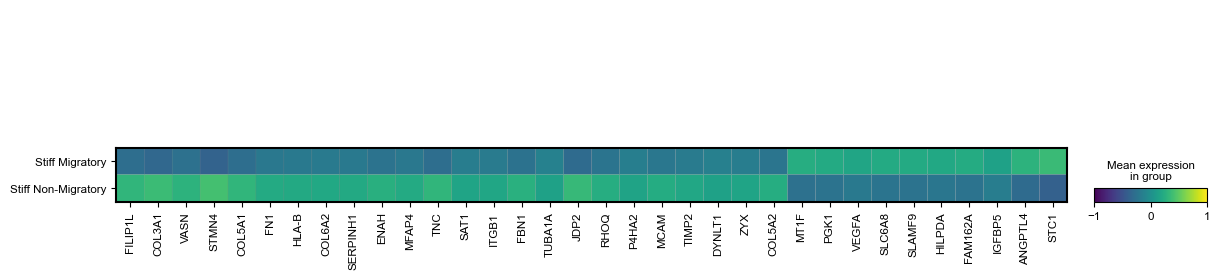

In [44]:
sc.pl.matrixplot(
    sc.pp.scale(ad_hk177[np.logical_or(ad_hk177.obs['sample'] == 'StiffMi', ad_hk177.obs['sample'] == 'StiffNon')], copy=True),
    #ad_hk177[np.logical_or(ad_hk177.obs['sample'] == 'StiffMi', ad_hk177.obs['sample'] == 'StiffNon')],
    var_names=unqiue_migration_interface.sort_values('coef').index,
    groupby='sample_name',
    vmax=1, vmin=-1
    #dendrogram=True
)

In [45]:
unqiue_migration_interface_plot =['FILIP1L','COL3A1','VASN','COL5A1','FN1','COL6A2','TNC','SAT1','TUBA1A','COL5A2','PGK1','MT1F','VEGFA','SLAMF9','FAM162A','IGFBP5','IGFBP5','STC1','SLC6A8','ITGB1']

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


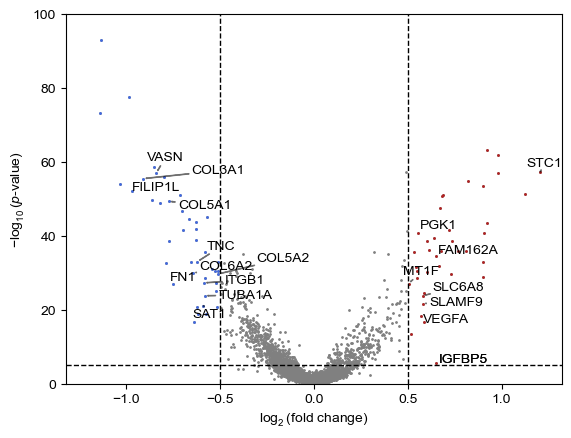

In [46]:
p_cutoff =0.00005
lfc_cutoff =0.5

plt.ylabel('$-\log_{10}(p$-value$)$')
plt.ylim((0, 100))

plt.xlabel('$\\log_2($fold change$)$')
plt.xlim(-1.2*1.1, 1.2*1.1)
#plt.vlines([-lfc_cutoff, lfc_cutoff], -0.5, 0.5, color='black', linestyles='--', alpha=1., linewidth=1)
plt.axhline(y=5, color='black', linestyle='--', linewidth=1)
plt.axvline(x=.5, color='black', linestyle='--', linewidth=1)
plt.axvline(x=-.5, color='black', linestyle='--', linewidth=1)

anns1 = []

plt.scatter(
    stiffmi_vs_stiffnon_hk177['coef'],
    -np.log10(stiffmi_vs_stiffnon_hk177['FDR']),
    s=1, color='grey'
)

for gene in stiffmi_vs_stiffnon_hk177.index:
    if stiffmi_vs_stiffnon_hk177.loc[gene, 'coef'] > lfc_cutoff:
        plt.scatter(
            stiffmi_vs_stiffnon_hk177.loc[gene, 'coef'],
            -np.log10(stiffmi_vs_stiffnon_hk177.loc[gene, 'FDR']),
            color='#b22222', s=1
        )
    if stiffmi_vs_stiffnon_hk177.loc[gene, 'coef'] < -lfc_cutoff:
        plt.scatter(
            stiffmi_vs_stiffnon_hk177.loc[gene, 'coef'],
            -np.log10(stiffmi_vs_stiffnon_hk177.loc[gene, 'FDR']),
            color='#4169e1', s=1
        )

for gene in unqiue_migration_interface_plot:        
        anns1.append(plt.text(
            stiffmi_vs_stiffnon_hk177.loc[gene, 'coef'],
            -np.log10(stiffmi_vs_stiffnon_hk177.loc[gene, 'FDR']),
            gene, fontweight='regular'))
        
adjust_text(anns1, arrowprops=dict(linewidth=1, color='black', alpha=0.5))

## Subpopulations

In [47]:
p_val = 0.00005
lfc_cutoff =0.25

misubp_vs_nonmisubp = pd.read_csv('mast_hk177/misubp_vs_nonmisubp.csv', index_col=0)
misubp_vs_nonmisubp.loc[(misubp_vs_nonmisubp['FDR'] < .00005) & (np.abs(misubp_vs_nonmisubp['coef']) > lfc_cutoff), :].sort_values('coef')

,Pr(>Chisq),coef,FDR
primerid,,,
PCAT1,2.188408e-97,-0.768405,1.971537e-93
SLAMF9,5.993166e-28,-0.724666,4.153264e-25
BGN,2.774745e-56,-0.693006,1.249884e-52
PVT1,4.319401e-11,-0.522622,4.988908e-09
TGFBI,2.295346e-18,-0.485987,6.892924e-16
...,...,...,...
TM4SF1,1.942184e-28,0.601449,1.458095e-25
MAP1LC3B,1.069191e-43,0.615581,2.408085e-40
NETO2,9.871381e-35,0.626364,1.778625e-31


In [48]:
misubp_vs_nonmisubp_plot = misubp_vs_nonmisubp.loc[(misubp_vs_nonmisubp['FDR'] < 0.0005) & (np.abs(misubp_vs_nonmisubp['coef']) > 0.5), :].sort_values('coef')
misubp_vs_nonmisubp_plot

,Pr(>Chisq),coef,FDR
primerid,,,
PCAT1,2.188408e-97,-0.768405,1.971537e-93
SLAMF9,5.993166e-28,-0.724666,4.153264e-25
BGN,2.774745e-56,-0.693006,1.249884e-52
PVT1,4.319401e-11,-0.522622,4.988908e-09
CPNE7,1.515084e-29,0.541410,1.240853e-26
CES1,1.009083e-29,0.548587,9.555376e-27
GNG11,7.953074e-20,0.553338,3.256784e-17
MMP2,1.249301e-19,0.587024,4.689563e-17
DCN,6.035023e-18,0.593302,1.647561e-15


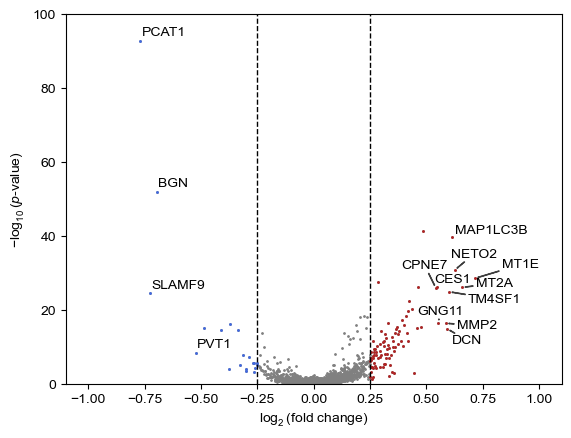

In [49]:
p_cutoff =0.00005
lfc_cutoff =0.25

plt.ylabel('$-\log_{10}(p$-value$)$')
plt.ylim((0, 100))

plt.xlabel('$\\log_2($fold change$)$')
plt.xlim(-1*1.1, 1*1.1)
#plt.vlines([-lfc_cutoff, lfc_cutoff], -0.5, 0.5, color='black', linestyles='--', alpha=1., linewidth=1)
#plt.axhline(y=4, color='black', linestyle='--', linewidth=1)
plt.axvline(x=.25, color='black', linestyle='--', linewidth=1)
plt.axvline(x=-.25, color='black', linestyle='--', linewidth=1)

anns1 = []

plt.scatter(
    misubp_vs_nonmisubp['coef'],
    -np.log10(misubp_vs_nonmisubp['FDR']),
    s=1, color='grey'
)

for gene in misubp_vs_nonmisubp.index:
    if misubp_vs_nonmisubp.loc[gene, 'coef'] > lfc_cutoff:
        plt.scatter(
            misubp_vs_nonmisubp.loc[gene, 'coef'],
            -np.log10(misubp_vs_nonmisubp.loc[gene, 'FDR']),
            color='firebrick', s=1
        )
    if misubp_vs_nonmisubp.loc[gene, 'coef'] < -lfc_cutoff:
        plt.scatter(
            misubp_vs_nonmisubp.loc[gene, 'coef'],
            -np.log10(misubp_vs_nonmisubp.loc[gene, 'FDR']),
            color='royalblue', s=1
        )

for gene in misubp_vs_nonmisubp_plot.index:        
        anns1.append(plt.text(
            misubp_vs_nonmisubp.loc[gene, 'coef'],
            -np.log10(misubp_vs_nonmisubp.loc[gene, 'FDR']),
            gene, fontweight='regular'))
        
adjust_text(anns1, arrowprops=dict(linewidth=1, color='black', alpha=0.7))

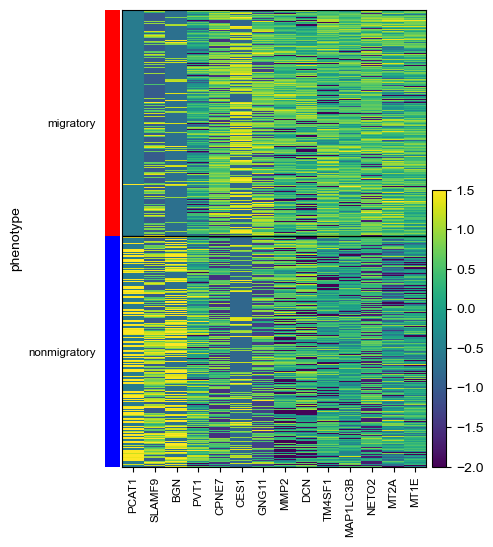

In [50]:
sc.pl.heatmap(
    sc.pp.scale(ad_hk177[np.logical_or(ad_hk177.obs['phenotype'] == 'migratory', ad_hk177.obs['phenotype'] == 'nonmigratory')], copy=True),
    var_names=misubp_vs_nonmisubp.loc[(misubp_vs_nonmisubp['FDR'] < 0.05) & (np.abs(misubp_vs_nonmisubp['coef']) > 0.5), :].sort_values('coef').index,
    groupby='phenotype',
    vmax=1.5, vmin=-2
    #dendrogram=True
)

In [51]:
p_val = 0.00005
lfc_cutoff =0.25

misubp_vs_nonmisubp_in_soft = pd.read_csv('mast_hk177/misubp_vs_nonmisubp_in_soft.csv', index_col=0)
misubp_vs_nonmisubp_in_soft.loc[(misubp_vs_nonmisubp_in_soft['FDR'] < 0.00005) & (np.abs(misubp_vs_nonmisubp['coef']) > lfc_cutoff), :].sort_values('coef')

,Pr(>Chisq),coef,FDR
primerid,,,
SLAMF9,6.552114e-18,-0.836864,8.426954e-15
PCAT1,4.676848e-49,-0.803431,4.210566e-45
BGN,7.389305e-28,-0.663031,3.326296e-24
PVT1,6.060874e-08,-0.619860,1.186796e-05
STAC2,1.391052e-11,-0.498303,5.218184e-09
IGFBP2,4.083119e-15,-0.479863,2.827717e-12
TGFBI,4.536754e-09,-0.475386,1.103903e-06
DMKN,1.508395e-07,-0.304632,2.425015e-05
SGCE,7.909724e-08,0.273654,1.453291e-05


In [52]:
p_val = 0.00005
lfc_cutoff =0.2

misubp_vs_nonmisubp_in_stiff = pd.read_csv('mast_hk177/misubp_vs_nonmisubp_in_stiff.csv', index_col=0)
misubp_vs_nonmisubp_in_stiff.loc[(misubp_vs_nonmisubp_in_stiff['FDR'] < p_val) & (np.abs(misubp_vs_nonmisubp['coef']) > lfc_cutoff), :].sort_values('coef')

,Pr(>Chisq),coef,FDR
primerid,,,
PCAT1,7.119895e-50,-0.748141,6.413601e-46
BGN,8.997029e-30,-0.731562,4.052262e-26
SLAMF9,1.287680e-13,-0.670860,9.666181e-11
TGFBI,1.260003e-09,-0.472685,2.986870e-07
DMKN,8.089917e-12,-0.383323,3.470189e-09
...,...,...,...
NETO2,7.538672e-20,0.662411,1.358167e-16
MMP2,2.151200e-13,0.668581,1.366494e-10
MT2A,7.674058e-15,0.683922,8.471232e-12


In [54]:
p_val = 0.0005
lfc_cutoff =0.25

misubp_vs_nonmisubp_in_stiffnon = pd.read_csv('mast_hk177/misubp_vs_nonmisubp_in_stiffnon.csv', index_col=0)
misubp_vs_nonmisubp_in_stiffnon.loc[(misubp_vs_nonmisubp_in_stiffnon['FDR'] < p_val) & (np.abs(misubp_vs_nonmisubp_in_stiffnon['coef']) > lfc_cutoff), :].sort_values('coef')

,Pr(>Chisq),coef,FDR
primerid,,,
BGN,1.559363e-13,-3.015425,4.687445e-10
LINC01551,1.866515e-09,-1.816423,3.366447e-06
SNHG4,2.922364e-07,-1.435696,1.464104e-04
HSBP1,9.032820e-08,0.298456,5.818426e-05
COX4I1,1.679272e-09,0.373536,3.366447e-06
CD99,2.694394e-07,0.555513,1.429297e-04
GABARAPL2,4.247226e-07,0.819268,1.915074e-04
MAP1LC3B,3.002925e-09,0.889626,4.513396e-06
DYNC1H1,6.045098e-07,0.955671,2.096719e-04


In [55]:
p_val = 0.005
lfc_cutoff =0.25

misubp_vs_nonmisubp_in_stiffmi= pd.read_csv('mast_hk177/misubp_vs_nonmisubp_in_stiffmi.csv', index_col=0)
misubp_vs_nonmisubp_in_stiffmi.loc[(misubp_vs_nonmisubp_in_stiffmi['FDR'] < 0.05) & (np.abs(misubp_vs_nonmisubp_in_stiffmi['coef']) > lfc_cutoff), :].sort_values('coef')

,Pr(>Chisq),coef,FDR
primerid,,,
PCAT1,5.922657e-28,-3.705409,5.341052e-24
BGN,7.122088e-17,-3.204187,3.211350e-13
SLAMF9,4.397568e-08,-2.709748,4.957158e-05
DMKN,1.757242e-06,-2.156303,6.338722e-04
SYNGR1,3.593435e-06,-1.874265,1.080186e-03
...,...,...,...
MT3,2.692140e-06,2.156468,8.371627e-04
GNG11,1.265452e-07,2.291950,7.607897e-05
MMP2,6.788318e-09,2.320383,8.745294e-06


In [56]:
p_val = 0.005
lfc_cutoff =0.1

misubp_vs_nonmisubp_in_softmi= pd.read_csv('mast_hk177/misubp_vs_nonmisubp_in_softmi.csv', index_col=0)
misubp_vs_nonmisubp_in_softmi.loc[(misubp_vs_nonmisubp_in_softmi['FDR'] < 0.05) & (np.abs(misubp_vs_nonmisubp_in_softmi['coef']) > lfc_cutoff), :].sort_values('coef')

,Pr(>Chisq),coef,FDR
primerid,,,
BGN,1.119278e-13,-3.076034,5.046824e-10
SLAMF9,1.355795e-05,-2.549400,4.702522e-03
DMKN,3.296084e-06,-2.270385,1.745537e-03
STAC2,1.586694e-05,-1.983379,5.299557e-03
PHF14,3.208887e-05,-1.889670,9.335752e-03
...,...,...,...
DCN,2.582120e-04,1.978431,3.326508e-02
MT3,1.678336e-04,1.981233,2.486692e-02
ARL2BP,1.378469e-08,2.101766,2.071839e-05


In [57]:
p_val = 0.05
lfc_cutoff =0.25

misubp_vs_nonmisubp_in_softnon= pd.read_csv('mast_hk177/misubp_vs_nonmisubp_in_softnon.csv', index_col=0)
misubp_vs_nonmisubp_in_softnon.loc[(misubp_vs_nonmisubp_in_softnon['FDR'] < 0.05) & (np.abs(misubp_vs_nonmisubp_in_softnon['coef']) > 0.1), :].sort_values('coef')

,Pr(>Chisq),coef,FDR
primerid,,,
PCAT1,1.663143e-25,-3.370970,1.499823e-21
SLAMF9,1.505211e-12,-3.016872,2.262332e-09
BGN,1.423393e-14,-2.810859,4.278720e-11
C1QL1,2.339270e-06,-1.686850,6.204569e-04
MRPL11,1.678934e-06,-1.615153,4.731445e-04
...,...,...,...
CITED4,2.806796e-07,1.995179,9.735264e-05
MPHOSPH6,2.552241e-08,2.026288,1.211374e-05
FOXC2,5.239880e-13,2.266705,9.450648e-10


In [59]:
lfc_cutoff =0.25
p_cutoff =0.000005

misub_stiff_sig = misubp_vs_nonmisubp_in_stiff.loc[(misubp_vs_nonmisubp_in_stiff['FDR'] < p_cutoff) & (np.abs(misubp_vs_nonmisubp_in_stiff['coef']) > 0.25)]
misub_soft_sig = misubp_vs_nonmisubp_in_soft.loc[(misubp_vs_nonmisubp_in_soft['FDR'] < p_cutoff) & (np.abs(misubp_vs_nonmisubp_in_soft['coef']) > 0.23), :]

stiffness_changed_misub = misub_stiff_sig.loc[~misub_stiff_sig.index.isin(misub_soft_sig.index)].copy()
stiffness_changed_misub = stiffness_changed_misub.sort_values('coef')
stiffness_changed_misub

len(stiffness_changed_misub)
stiffness_changed_misub


,Pr(>Chisq),coef,FDR
primerid,,,
DMKN,8.089917e-12,-0.383323,3.470189e-09
SGCE,3.097454e-08,0.261284,4.895063e-06
GJA1,1.147593e-11,0.308979,4.135008e-09
CRNDE,6.806735e-09,0.319186,1.304576e-06
RSPRY1,1.624268e-09,0.324056,3.651611e-07
H19,6.383247e-12,0.331970,2.875014e-09
MBTPS1,1.850379e-08,0.334804,3.144945e-06
DEF8,1.796471e-08,0.339574,3.112041e-06
CHD9,2.748323e-08,0.351587,4.420874e-06


/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be igno

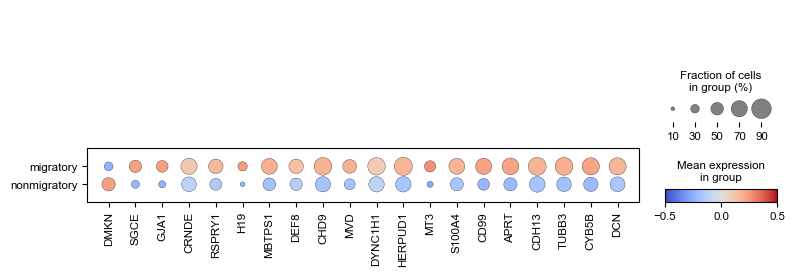

In [60]:
sc.pl.dotplot(
    sc.pp.scale(ad_hk177[ad_hk177.obs['phenotype'] != ''], copy=True),
    var_names=stiffness_changed_misub.index,
    groupby='phenotype',
    vmax=0.5, vmin=-0.5,
    cmap='coolwarm'
    #dendrogram=True
)

In [61]:
p_val = 0.00005
lfc_cutoff =0.25

misubp_vs_nonmisubp_in_top = pd.read_csv('mast_hk177/misubp_vs_nonmisubp_in_top.csv', index_col=0)
misubp_vs_nonmisubp_in_top.loc[(misubp_vs_nonmisubp_in_stiff['FDR'] < 0.05) & (np.abs(misubp_vs_nonmisubp['coef']) > lfc_cutoff), :].sort_values('coef')

,Pr(>Chisq),coef,FDR
primerid,,,
PCAT1,2.642196e-47,-0.770317,2.380354e-43
SLAMF9,7.444197e-18,-0.756125,7.451641e-15
BGN,3.793331e-27,-0.708160,1.708706e-23
PVT1,1.307984e-05,-0.506830,1.033651e-03
TGFBI,2.808428e-10,-0.493384,6.487468e-08
...,...,...,...
MMP2,2.782544e-11,0.592307,8.952835e-09
DCN,1.620982e-10,0.625898,4.172407e-08
MT1E,1.570674e-15,0.687960,1.088477e-12


In [62]:
lfc_cutoff =0.20

phenotype_interest = misubp_vs_nonmisubp.loc[
    (misubp_vs_nonmisubp['FDR'] < p_cutoff) & 
    (np.abs(misubp_vs_nonmisubp['coef']) > lfc_cutoff) & 
    (stiffmi_vs_stiffnon_hk177['FDR'] < p_cutoff) & 
    (np.abs(stiffmi_vs_stiffnon_hk177['coef']) > lfc_cutoff) &
    (softmi_vs_softnon_hk177['FDR'] < p_cutoff) & 
    (np.abs(softmi_vs_softnon_hk177['coef']) > lfc_cutoff), :].sort_values('coef')

phenotype_interest

,Pr(>Chisq),coef,FDR
primerid,,,
TGFBI,2.295346e-18,-0.485987,6.892924e-16
CMBL,1.271079e-10,-0.311460,1.379657e-08
TPM1,7.051818e-08,0.247793,4.812866e-06
LGALS1,4.087093e-09,0.255128,3.409317e-07
NAMPT,3.296714e-08,0.265411,2.414642e-06
TFPI,1.608031e-10,0.343746,1.665144e-08
CD99,2.081306e-18,0.368288,6.465684e-16
IGFBP7,8.668139e-30,0.464836,9.555376e-27
MMP2,1.249301e-19,0.587024,4.689563e-17


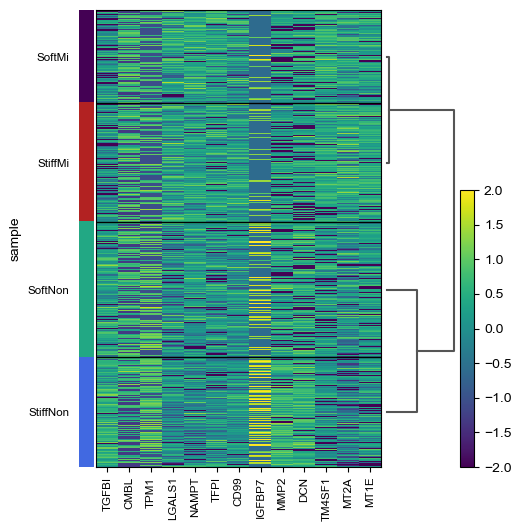

In [63]:
sc.pl.heatmap(
    sc.pp.scale(ad_hk177[ad_hk177.obs['sample'] != ''], copy=True),
    var_names=phenotype_interest.index,
    groupby='sample',
    vmax=2, vmin=-2,
    dendrogram=True
)

/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be igno

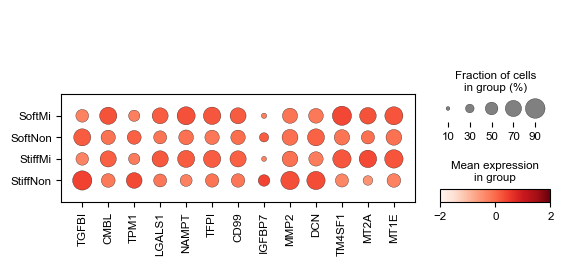

In [64]:
sc.pl.dotplot(
    sc.pp.scale(ad_hk177[ad_hk177.obs['sample'] != ''], copy=True),
    var_names=phenotype_interest.index,
    groupby='sample',
    vmax=2, vmin=-2
    #dendrogram=True
)

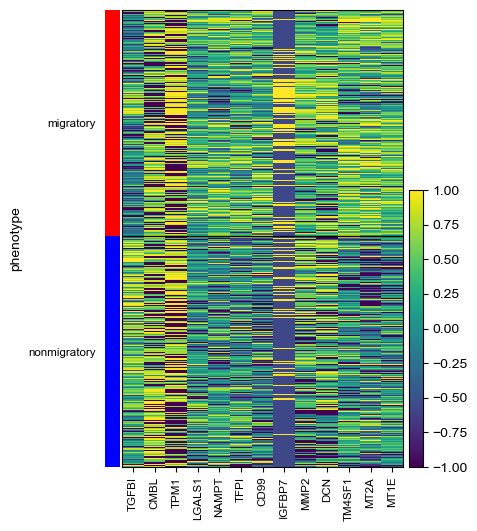

In [65]:
sc.pl.heatmap(
    sc.pp.scale(ad_hk177[ad_hk177.obs['phenotype'] != ''], copy=True),
    var_names=phenotype_interest.index,
    groupby='phenotype',
    vmax=1, vmin=-1
    #dendrogram=True
)

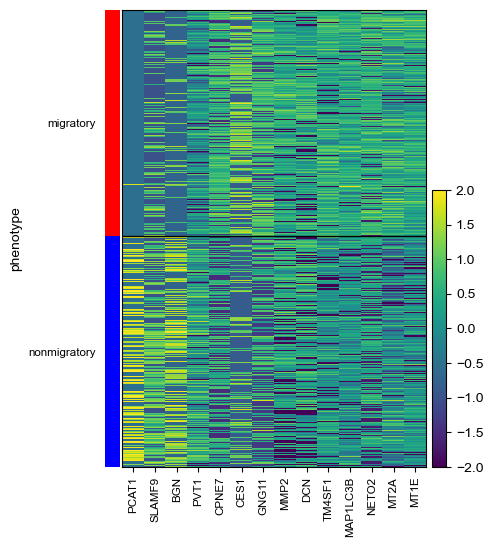

In [66]:
sc.pl.heatmap(
    sc.pp.scale(ad_hk177[ad_hk177.obs['phenotype'] != ''], copy=True),
    var_names=misubp_vs_nonmisubp.loc[(misubp_vs_nonmisubp['FDR'] < p_cutoff) & (np.abs(misubp_vs_nonmisubp['coef']) > 0.5), :].sort_values('coef').index,
    groupby='phenotype',
    vmax=2, vmin=-2
    #dendrogram=True
)

In [67]:
misubp_vs_nonmisubp_in_stiffnon = pd.read_csv('mast_hk177/misubp_vs_nonmisubp_in_stiffnon.csv', index_col=0)
misubp_vs_nonmisubp_in_stiffnon.loc[(misubp_vs_nonmisubp_in_stiffnon['FDR'] < 0.05) & (np.abs(misubp_vs_nonmisubp_in_stiffnon['coef']) > lfc_cutoff), :].sort_values('coef')

,Pr(>Chisq),coef,FDR
primerid,,,
BGN,1.559363e-13,-3.015425,4.687445e-10
SLAMF9,3.642311e-06,-2.035063,8.973405e-04
CMBL,7.841398e-06,-1.822091,1.724725e-03
LINC01551,1.866515e-09,-1.816423,3.366447e-06
DMKN,4.628393e-06,-1.788732,1.070227e-03
...,...,...,...
GJA1,7.545024e-07,1.891325,2.430037e-04
RSPRY1,3.012513e-08,1.993969,2.469713e-05
FOXC2,3.441676e-07,2.018703,1.633528e-04


# GS54

In [68]:
ad_gs54 = sc.read_h5ad('GS54_cleaned.h5ad')
ad_gs54.X = ad_gs54.layers['norm_counts']
ad_gs54 = ad_gs54[:, np.mean(ad_gs54.X != 0., axis=0) > 0.1]
ad_gs54

View of AnnData object with n_obs × n_vars = 4943 × 3289
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'doublet_score', 'predicted_doublets', 'S_score', 'G2M_score', 'phase', 'cc_difference'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'Processing', 'log1p', 'sample_colors'
    layers: 'cc_regressed', 'counts', 'cpm', 'norm_counts'

In [69]:
ad_gs54.obs['sample_name'] = ad_gs54.obs['sample'].map({
    'SoftMi':'Soft Migratory',
    'SoftNon': 'Soft Non-Migratory',
    'StiffMi': 'Stiff Migratory',
    'StiffNon':'Stiff Non-Migratory'
    })

/tmp/ipykernel_491669/3894655474.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  ad_gs54.obs['sample_name'] = ad_gs54.obs['sample'].map({


In [70]:
ad_gs54.uns['sample_colors']=['#440154ff','#22a884ff','#b22222','#4169e1']

In [71]:
ad_gs54.X = ad_gs54.layers['cc_regressed']
sc.pp.pca(ad_gs54)
sc.pp.neighbors(ad_gs54)
sc.tl.umap(ad_gs54)
ad_gs54.X = ad_gs54.layers['norm_counts']

/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


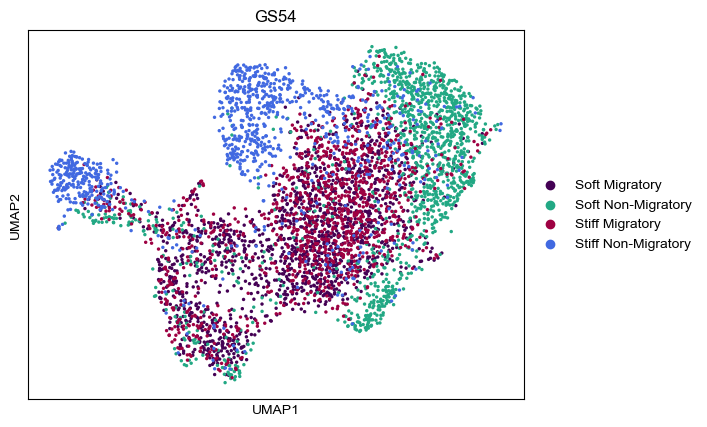

In [72]:
sc.pl.umap(
    ad_gs54,
    color='sample_name',
    palette =['#440154ff','#22a884ff','#9e0142','#4169e1'],
    layer = 'cc_regressed',
    title ='GS54',
    #save = ('GS54_UMAP.svg')
)

/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/tools/_dendrogram.py:135: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = rep_df.groupby(level=0).mean()


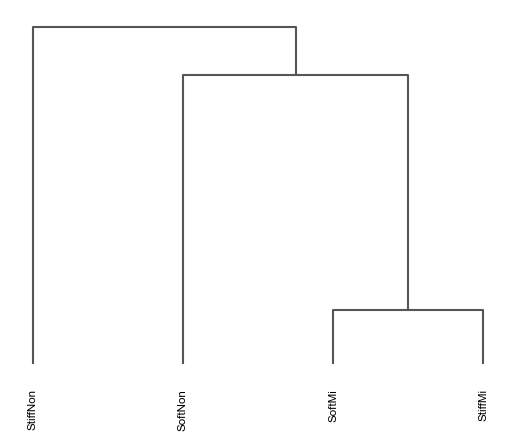

<Axes: >

In [73]:
sc.pl.dendrogram(ad_gs54, groupby='sample')

We add two new `obs` - one for `substrate` that says if the cells came from/are in a stiff gel (StiffMi and StiffNon vs. SoftMi and SoftNon), and one for `gel_side` that says if cells migrated through the gel - `'bottom'`, or if cells stayed in the top gel - `'top'` (StiffMi and SoftMi vs StiffNon and SoftNon).

In [74]:
ad_gs54.obs['substrate'] = ['soft' if c.startswith('Soft') else 'stiff' for c in ad_gs54.obs['sample']]
ad_gs54.obs['gel_side'] = ['bottom' if c.endswith('Mi') else 'top' for c in ad_gs54.obs['sample']]
ad_gs54.obs['substrate']

AAACCGCTCAGCTACA-1     soft
AAACCGCTCGATTGGC-1     soft
AAACGAATCTGGGACT-1     soft
AAACGAATCTGTCACT-1     soft
AAACGCCTCCTGACCC-1     soft
                      ...  
TGTCGTCCAACTATCT-4    stiff
TGTCGTCCACTTCACA-4    stiff
TGTCTCACATGAATTG-4    stiff
TGTCTTGCAAGTATCA-4    stiff
TGTGAACCATTAGACA-4    stiff
Name: substrate, Length: 4943, dtype: object

/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.

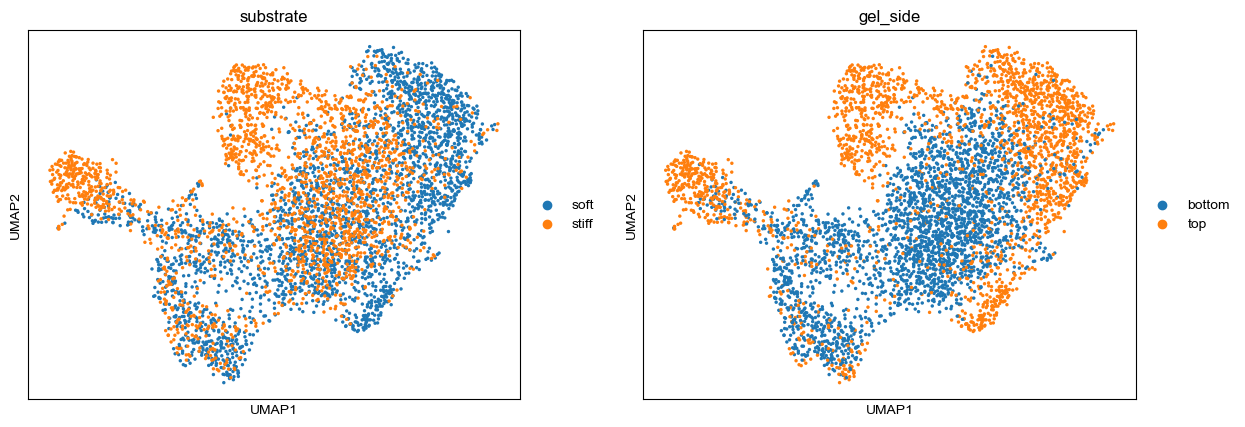

In [75]:
sc.pl.umap(
    ad_gs54,
    color=['substrate', 'gel_side']
)

## stiff vs. soft

In [76]:
stiff_vs_soft_gs54 = pd.read_csv('mast_gs54/stiff_vs_soft.csv', index_col=0)
stiff_vs_soft_gs54.loc[(stiff_vs_soft_gs54['FDR'] < p_cutoff) & (np.abs(stiff_vs_soft_gs54['coef']) > lfc_cutoff), :].sort_values('coef')

,Pr(>Chisq),coef,FDR
primerid,,,
MIF,1.296264e-89,-0.497881,5.329264e-87
HIST1H1E,6.045416e-31,-0.466872,2.285445e-29
TUBB,7.466941e-38,-0.407191,4.162503e-36
TUBA1A,5.646530e-26,-0.383602,1.703802e-24
RPS19,1.331613e-55,-0.372856,2.305092e-53
...,...,...,...
VIM,3.711854e-58,0.658636,7.181345e-56
FOS,8.437764e-110,0.776358,5.550361e-107
TRIB1,1.895273e-135,0.826642,2.077851e-132


In [77]:
p_cutoff = 0.000005
lfc_cutoff = 0.5

stiffnon_vs_softnon_gs54 = pd.read_csv('mast_gs54/stiffnon_vs_softnon.csv', index_col=0)
stiffnon_vs_softnon_gs54=stiffnon_vs_softnon_gs54.loc[~stiffnon_vs_softnon_gs54.index.str.startswith(('RPL','RPS'))]
stiffnon_vs_softnon_gs54.loc[(stiffnon_vs_softnon_gs54['FDR'] < p_cutoff) & (np.abs(stiffnon_vs_softnon_gs54['coef']) > lfc_cutoff), :].sort_values('coef')


,Pr(>Chisq),coef,FDR
primerid,,,
MIF,2.752128e-141,-1.263016,9.051749e-139
VEGFA,6.287774e-61,-1.024533,2.651345e-59
GAPDH,1.609668e-55,-0.855911,6.016135e-54
DDIT4,7.787514e-156,-0.818648,3.201641e-153
ATOX1,4.665675e-64,-0.801265,2.223972e-62
...,...,...,...
VIM,8.099524e-120,1.463281,2.421758e-117
FOS,6.306166e-197,1.732085,3.456830e-194
ATF3,5.919243e-271,1.929327,6.489463e-268


Text(0, 0.5, '')

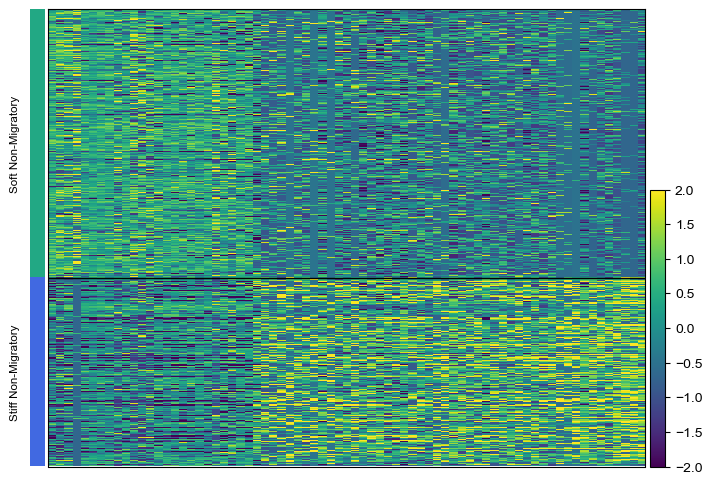

In [78]:
p_cutoff = 0.00005
lfc_cutoff = 0.5

axs= sc.pl.heatmap(
    sc.pp.scale(ad_gs54[np.logical_or(ad_gs54.obs['sample'] == 'StiffNon', ad_gs54.obs['sample'] == 'SoftNon')], copy=True),
    var_names=stiffnon_vs_softnon_gs54.loc[(stiffnon_vs_softnon_gs54['FDR'] < p_cutoff) & (np.abs(stiffnon_vs_softnon_gs54['coef']) > lfc_cutoff), :].sort_values('coef').index,
    groupby='sample_name',
    vmax=2, vmin=-2,
    cmap='viridis',
    swap_axes=False,
    #dendrogram=True
    show = False
)
axs['groupby_ax'].set_yticks(axs['groupby_ax'].get_yticks(), axs['groupby_ax'].get_yticklabels(), rotation=90, ha='right', va='center')
axs['groupby_ax'].set_ylabel('')
#plt.savefig('stiffnon_vs_softnon_gs54_heatmap.svg',  bbox_inches='tight')

In [79]:
stiffnonmi_genes = stiff_vs_soft_gs54.loc[(stiff_vs_soft_gs54['FDR'] < p_cutoff) & (np.abs(stiff_vs_soft_gs54['coef']) > lfc_cutoff), :].sort_values('coef')
stiffnonmi_genes

,Pr(>Chisq),coef,FDR
primerid,,,
DDX5,2.915247e-111,0.532789,2.397062e-108
FOSB,9.578633e-81,0.555282,2.864011e-78
COL11A1,9.557246e-82,0.613903,3.143378e-79
VIM,3.711854e-58,0.658636,7.181345e-56
FOS,8.437764e-110,0.776358,5.550361e-107
TRIB1,1.895273e-135,0.826642,2.077851e-132
ATF3,9.234718e-143,0.859208,1.518649e-139
JUN,3.424489e-154,1.113430,1.126315e-150


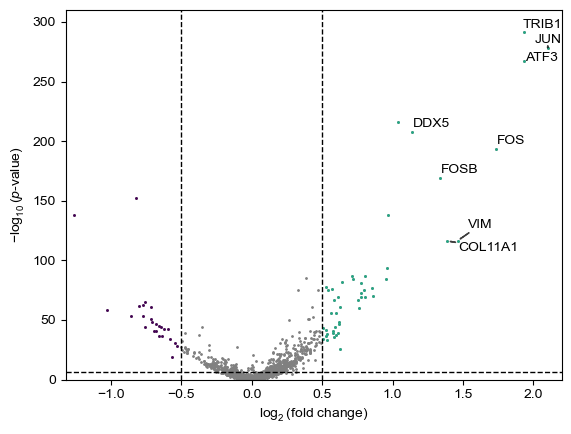

In [80]:
p_cutoff =0.00005
lfc_cutoff =0.5

plt.ylabel('$-\log_{10}(p$-value$)$')
plt.ylim((0, 310))

plt.xlabel('$\\log_2($fold change$)$')
plt.xlim(-1.2*1.1, 2*1.1)
#plt.vlines([-lfc_cutoff, lfc_cutoff], -0.5, 0.5, color='black', linestyles='--', alpha=1., linewidth=1)
plt.axhline(y=6, color='black', linestyle='--', linewidth=1)
plt.axvline(x=.5, color='black', linestyle='--', linewidth=1)
plt.axvline(x=-.5, color='black', linestyle='--', linewidth=1)

anns1 = []

plt.scatter(
    stiffnon_vs_softnon_gs54['coef'],
    -np.log10(stiffnon_vs_softnon_gs54['FDR']),
    s=1, color='grey'
)

for gene in stiffnon_vs_softnon_gs54.index:
    if stiffnon_vs_softnon_gs54.loc[gene, 'coef'] > lfc_cutoff:
        plt.scatter(
            stiffnon_vs_softnon_gs54.loc[gene, 'coef'],
            -np.log10(stiffnon_vs_softnon_gs54.loc[gene, 'FDR']),
            color='#22A884ff', s=1
        )
    if stiffnon_vs_softnon_gs54.loc[gene, 'coef'] < -lfc_cutoff:
        plt.scatter(
            stiffnon_vs_softnon_gs54.loc[gene, 'coef'],
            -np.log10(stiffnon_vs_softnon_gs54.loc[gene, 'FDR']),
            color='#440154ff', s=1
        )

for gene in stiffnonmi_genes.index:        
        anns1.append(plt.text(
            stiffnon_vs_softnon_gs54.loc[gene, 'coef'],
            -np.log10(stiffnon_vs_softnon_gs54.loc[gene, 'FDR']),
            gene, fontweight='regular'))
        
adjust_text(anns1, arrowprops=dict(linewidth=1, color='black', alpha=0.7))

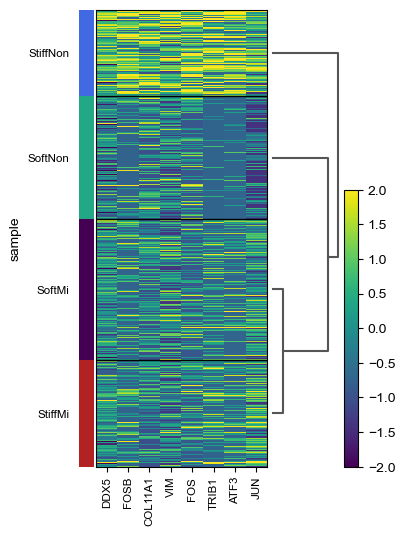

In [81]:
sc.pl.heatmap(
    sc.pp.scale(ad_gs54, copy=True),
    var_names=stiff_vs_soft_gs54.loc[(stiff_vs_soft_gs54['FDR'] < p_cutoff) & (np.abs(stiff_vs_soft_gs54['coef']) > 0.5), :].sort_values('coef').index,
    groupby='sample',
    vmax=2, vmin=-2,
    dendrogram=True
)

In [82]:
top_vs_bottom_gs54 = pd.read_csv('mast_gs54/top_vs_bottom.csv', index_col=0)
top_vs_bottom_gs54.loc[(top_vs_bottom_gs54['FDR'] < p_cutoff) & (np.abs(top_vs_bottom_gs54['coef']) > lfc_cutoff), :].sort_values('coef')

,Pr(>Chisq),coef,FDR
primerid,,,
MALAT1,2.354619e-117,-0.780008,4.840214e-115
COL11A1,6.912826e-114,-0.745199,1.337429e-111
MTRNR2L6,2.386510e-92,-0.681989,2.452885e-90
ZBTB20,5.574873e-111,-0.609296,9.650398e-109
VEGFA,1.630263e-94,-0.590241,1.848943e-92
SPARC,9.089853e-176,-0.548802,7.474132e-173
SOX4,6.416775e-70,-0.536441,2.972503e-68
PNISR,1.596968e-96,-0.534198,1.875867e-94
CRYAB,7.304451e-79,-0.530223,5.111562e-77


/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/tools/_dendrogram.py:135: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = rep_df.groupby(level=0).mean()


Text(0, 0.5, '')

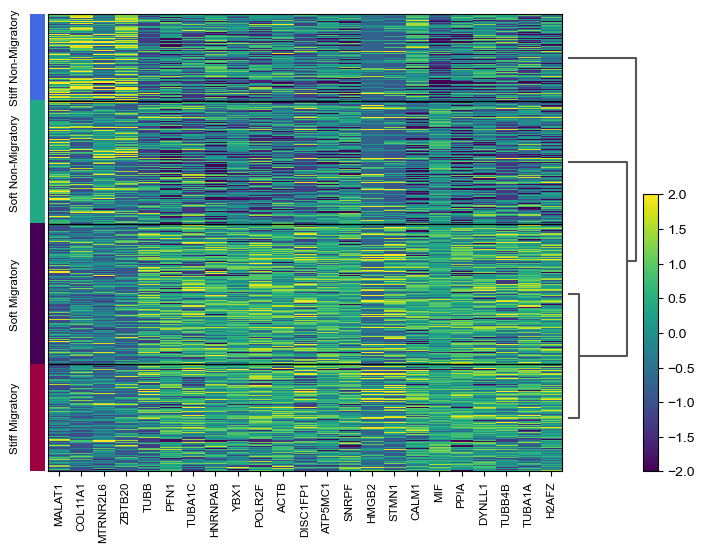

In [83]:
axs = sc.pl.heatmap(
    sc.pp.scale(ad_gs54, copy=True),
    var_names=top_vs_bottom_gs54.loc[(top_vs_bottom_gs54['FDR'] < p_cutoff) & (np.abs(top_vs_bottom_gs54['coef']) > 0.6), :].sort_values('coef').index,
    groupby='sample_name',
    vmax=2, vmin=-2,
    dendrogram=True,
    show = False
)
axs['groupby_ax'].set_yticks(axs['groupby_ax'].get_yticks(), axs['groupby_ax'].get_yticklabels(), rotation=90, ha='right', va='center')
axs['groupby_ax'].set_ylabel('')
#plt.savefig('figures/top_v_bottom_gs54_heatmap.svg',  bbox_inches='tight')

In [84]:
p_cutoff = 0.0005
lfc_cutoff = 0.20

stiffmi_vs_softmi_gs54 = pd.read_csv('mast_gs54/stiffmi_vs_softmi.csv', index_col=0)
stiffmi_vs_softmi_gs54.loc[(stiffmi_vs_softmi_gs54['FDR'] < p_cutoff) & (np.abs(stiffmi_vs_softmi_gs54['coef']) > lfc_cutoff), :].sort_values('coef')

,Pr(>Chisq),coef,FDR
primerid,,,
HNRNPA3,1.723240e-20,-0.346003,5.667737e-17
HNRNPA2B1,1.933721e-15,-0.273038,3.180005e-12
TUBA1A,1.434010e-08,-0.241193,3.368900e-06
STMN1,1.033906e-06,-0.229680,8.948725e-05
ATP5MC3,1.934571e-10,-0.225156,7.953505e-08
NUCKS1,2.369261e-08,-0.220175,4.583823e-06
ATP5MC1,2.222839e-11,-0.212550,1.462183e-08
TUBB,7.063003e-06,-0.210313,4.467349e-04
MTRNR2L1,1.198555e-07,0.208663,1.407874e-05


In [85]:
p_cutoff =0.00005
lfc_cutoff =0.5

stiffmi_vs_stiffnon_gs54 = pd.read_csv('mast_gs54/stiffmi_vs_stiffnon.csv', index_col=0)
stiffmi_vs_stiffnon_gs54=stiffmi_vs_stiffnon_gs54.loc[~stiffmi_vs_stiffnon_gs54.index.str.startswith(('RPL','RPS'))]
stiffmi_vs_stiffnon_gs54.loc[(stiffmi_vs_stiffnon_gs54['FDR'] < p_cutoff) & (np.abs(stiffmi_vs_stiffnon_gs54['coef']) > lfc_cutoff), :].sort_values('coef')

,Pr(>Chisq),coef,FDR
primerid,,,
COL11A1,1.051748e-137,-1.559775,8.647997e-135
FOS,1.167685e-142,-1.487408,1.280172e-139
ATF3,1.175589e-109,-1.329559,5.523590e-107
TRIB1,4.752863e-107,-1.229121,1.736907e-104
VIM,5.914164e-74,-1.172316,6.483895e-72
...,...,...,...
SNRPF,4.568835e-81,0.896944,6.261207e-79
H2AFZ,7.075788e-71,0.966155,7.052202e-69
FAM162A,3.733502e-103,1.016387,1.116317e-100


In [86]:
softmi_vs_softnon_gs54 = pd.read_csv('mast_gs54/softmi_vs_softnon.csv', index_col=0)
softmi_vs_softnon_gs54.loc[(softmi_vs_softnon_gs54['FDR'] < p_cutoff) & (np.abs(softmi_vs_softnon_gs54['coef']) > lfc_cutoff), :].sort_values('coef')

,Pr(>Chisq),coef,FDR
primerid,,,
VEGFA,6.903059e-140,-1.162411,4.540833e-137
SOX4,1.074295e-112,-0.939447,3.533355e-110
DDIT4,2.705980e-123,-0.683509,1.271424e-120
MTRNR2L6,3.567145e-67,-0.627624,3.087458e-65
PNISR,4.060015e-67,-0.581006,3.423946e-65
CRYAB,1.026108e-57,-0.578808,7.030978e-56
HIST1H1E,2.068900e-37,-0.539159,5.766621e-36
MTRNR2L1,7.931172e-47,-0.534211,3.387744e-45
RPL13A,8.436239e-83,-0.530857,1.387340e-80


In [87]:
lfc_cutoff =0.5
p_cutoff =0.00005

gs54_mi_sig = top_vs_bottom_gs54.loc[(top_vs_bottom_gs54['FDR'] < p_cutoff) & (np.abs(top_vs_bottom_gs54['coef']) > 0.5)]
gs54_softmi_sig = softmi_vs_softnon_gs54.loc[(softmi_vs_softnon_gs54['FDR'] < p_cutoff) & (np.abs(softmi_vs_softnon_gs54['coef']) > 0.5), :]

stiffness_independent_mi_gs54 = gs54_mi_sig.loc[~gs54_mi_sig.index.isin(gs54_softmi_sig.index)].copy()
stiffness_independent_mi_gs54.sort_values('coef')

,Pr(>Chisq),coef,FDR
primerid,,,
COL11A1,6.912826e-114,-0.745199,1.337429e-111
ZBTB20,5.574873e-111,-0.609296,9.650398e-109
SPARC,9.089853e-176,-0.548802,7.474132e-173
MTRNR2L12,1.201777e-54,-0.527582,3.529147e-53
SRRM2,1.301373e-81,-0.511499,9.727761e-80
POMP,8.363288e-85,0.520217,7.238646e-83
NPM1,6.510422e-90,0.525480,6.487459e-88
PHB,6.706403e-90,0.530316,6.487459e-88
FAM162A,7.290292e-72,0.549657,3.746526e-70


In [88]:
lfc_cutoff =0.55
p_cutoff =0.000005

stiffmi_sig_gs54 = stiffmi_vs_stiffnon_gs54.loc[(stiffmi_vs_stiffnon_gs54['FDR'] < p_cutoff) & (np.abs(stiffmi_vs_stiffnon_gs54['coef']) > lfc_cutoff)]
softmi_sig_gs54 = softmi_vs_softnon_gs54.loc[(softmi_vs_softnon_gs54['FDR'] < p_cutoff) & (np.abs(softmi_vs_softnon_gs54['coef']) > 0.1)]

unqiue_migration_interface_gs54 = stiffmi_sig_gs54.loc[~stiffmi_sig_gs54.index.isin(softmi_sig_gs54.index)].copy()
unqiue_migration_interface_gs54.sort_values('coef')

,Pr(>Chisq),coef,FDR
primerid,,,
KIF21A,1.762903e-102,-1.045408,4.831822e-100
AHNAK,1.869394e-128,-0.970531,1.024740e-125
ANKRD28,1.242083e-76,-0.895524,1.459004e-74
ERBIN,3.016652e-83,-0.854556,4.509895e-81
AZIN1,1.365028e-84,-0.816780,2.137894e-82
CCNL1,2.376312e-65,-0.753247,2.004023e-63
MACF1,1.218724e-50,-0.677325,5.416732e-49
JMJD1C,5.788846e-54,-0.592245,3.022145e-52
STAT3,8.611500e-63,-0.586883,6.437096e-61


In [89]:
unqiue_migration_interface_gs54=unqiue_migration_interface_gs54.loc[~unqiue_migration_interface_gs54.index.str.startswith(('RPL','RPS'))]
unqiue_migration_interface_gs54.sort_values('coef')

,Pr(>Chisq),coef,FDR
primerid,,,
KIF21A,1.762903e-102,-1.045408,4.831822e-100
AHNAK,1.869394e-128,-0.970531,1.024740e-125
ANKRD28,1.242083e-76,-0.895524,1.459004e-74
ERBIN,3.016652e-83,-0.854556,4.509895e-81
AZIN1,1.365028e-84,-0.816780,2.137894e-82
CCNL1,2.376312e-65,-0.753247,2.004023e-63
MACF1,1.218724e-50,-0.677325,5.416732e-49
JMJD1C,5.788846e-54,-0.592245,3.022145e-52
STAT3,8.611500e-63,-0.586883,6.437096e-61


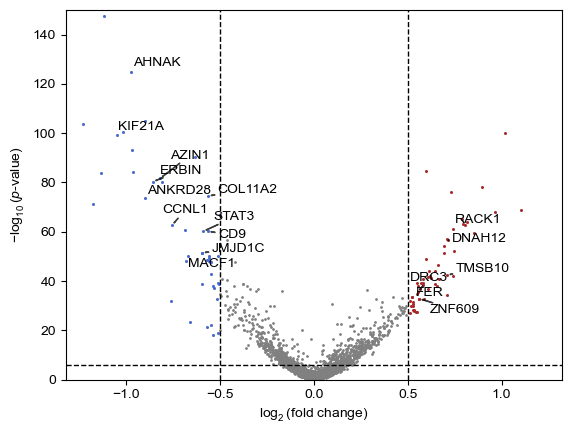

In [90]:
p_cutoff =0.00005
lfc_cutoff =0.5

plt.ylabel('$-\log_{10}(p$-value$)$')
plt.ylim((0, 150))

plt.xlabel('$\\log_2($fold change$)$')
plt.xlim(-1.2*1.1, 1.2*1.1)
#plt.vlines([-lfc_cutoff, lfc_cutoff], -0.5, 0.5, color='black', linestyles='--', alpha=1., linewidth=1)
plt.axhline(y=6, color='black', linestyle='--', linewidth=1)
plt.axvline(x=.5, color='black', linestyle='--', linewidth=1)
plt.axvline(x=-.5, color='black', linestyle='--', linewidth=1)

anns1 = []

plt.scatter(
    stiffmi_vs_stiffnon_gs54['coef'],
    -np.log10(stiffmi_vs_stiffnon_gs54['FDR']),
    s=1, color='grey'
)

for gene in stiffmi_vs_stiffnon_gs54.index:
    if stiffmi_vs_stiffnon_gs54.loc[gene, 'coef'] > lfc_cutoff:
        plt.scatter(
            stiffmi_vs_stiffnon_gs54.loc[gene, 'coef'],
            -np.log10(stiffmi_vs_stiffnon_gs54.loc[gene, 'FDR']),
            color='firebrick', s=1
        )
    if stiffmi_vs_stiffnon_gs54.loc[gene, 'coef'] < -lfc_cutoff:
        plt.scatter(
            stiffmi_vs_stiffnon_gs54.loc[gene, 'coef'],
            -np.log10(stiffmi_vs_stiffnon_gs54.loc[gene, 'FDR']),
            color='royalblue', s=1
        )

for gene in unqiue_migration_interface_gs54.index:        
        anns1.append(plt.text(
            stiffmi_vs_stiffnon_gs54.loc[gene, 'coef'],
            -np.log10(stiffmi_vs_stiffnon_gs54.loc[gene, 'FDR']),
            gene, fontweight='regular'))
        
adjust_text(anns1, arrowprops=dict(linewidth=1, color='black', alpha=0.7))

In [91]:
lfc_cutoff =0.20

gs54_phenotype_interest = misubp_vs_nonmisubp.loc[
    (misubp_vs_nonmisubp['FDR'] < p_cutoff) & 
    (np.abs(misubp_vs_nonmisubp['coef']) > lfc_cutoff) & 
    (stiffmi_vs_stiffnon_gs54['FDR'] < p_cutoff) & 
    (np.abs(stiffmi_vs_stiffnon_gs54['coef']) > lfc_cutoff)&
    (softmi_vs_softnon_gs54['FDR'] < p_cutoff) & 
    (np.abs(softmi_vs_softnon_gs54['coef']) > lfc_cutoff), :].sort_values('coef')

gs54_phenotype_interest

,Pr(>Chisq),coef,FDR
primerid,,,
DYNLL1,1.863989e-08,0.234114,1.460233e-06
TPM1,7.051818e-08,0.247793,4.812866e-06
LGALS1,4.087093e-09,0.255128,3.409317e-07
NUTF2,1.066087e-09,0.284723,9.800389e-08


In [92]:
misubp_vs_nonmisubp.loc[
    misubp_vs_nonmisubp.loc[(misubp_vs_nonmisubp['FDR'] < p_cutoff) & (np.abs(misubp_vs_nonmisubp['coef']) > lfc_cutoff), :].index.intersection(
    stiffmi_vs_stiffnon_hk177.loc[(stiffmi_vs_stiffnon_hk177['FDR'] < p_cutoff) & (np.abs(stiffmi_vs_stiffnon_hk177['coef']) > lfc_cutoff), :].index).intersection(
    stiffmi_vs_stiffnon_gs54.loc[(stiffmi_vs_stiffnon_gs54['FDR'] < p_cutoff) & (np.abs(stiffmi_vs_stiffnon_gs54['coef']) > lfc_cutoff), :].index), :]

,Pr(>Chisq),coef,FDR
primerid,,,
LGALS1,4.087093e-09,0.255128,3.409317e-07
TCF25,3.079296e-17,0.377806,7.113175e-15
TPM1,7.051818e-08,0.247793,4.812866e-06


In [93]:
genes_of_intrest = misubp_vs_nonmisubp.loc[
    misubp_vs_nonmisubp.loc[(misubp_vs_nonmisubp['FDR'] < p_cutoff) & (np.abs(misubp_vs_nonmisubp['coef']) > lfc_cutoff), :].index.intersection(
    stiffmi_vs_stiffnon_hk177.loc[(stiffmi_vs_stiffnon_hk177['FDR'] < p_cutoff) & ((stiffmi_vs_stiffnon_hk177['coef']) > lfc_cutoff), :].index).intersection(
    stiffmi_vs_stiffnon_gs54.loc[(stiffmi_vs_stiffnon_gs54['FDR'] < p_cutoff) & ((stiffmi_vs_stiffnon_gs54['coef']) > lfc_cutoff), :].index), :]

genes_of_intrest

,Pr(>Chisq),coef,FDR
primerid,,,
LGALS1,4.087093e-09,0.255128,3.409317e-07


In [94]:
top_vs_bottom_genes_of_intrest = misubp_vs_nonmisubp.loc[
    misubp_vs_nonmisubp.loc[(misubp_vs_nonmisubp['FDR'] < p_cutoff) & (np.abs(misubp_vs_nonmisubp['coef']) > lfc_cutoff), :].index.intersection(
    top_vs_bottom_hk177.loc[(top_vs_bottom_hk177['FDR'] < p_cutoff) & (np.abs(top_vs_bottom_hk177['coef']) > lfc_cutoff), :].index).intersection(
    top_vs_bottom_gs54.loc[(top_vs_bottom_gs54['FDR'] < p_cutoff) & (np.abs(top_vs_bottom_gs54['coef']) > lfc_cutoff), :].index), :]

top_vs_bottom_genes_of_intrest

,Pr(>Chisq),coef,FDR
primerid,,,
LGALS1,4.087093e-09,0.255128,3.409317e-07
MT-ND1,1.566786e-07,-0.326273,1.001076e-05
TPM1,7.051818e-08,0.247793,4.812866e-06


In [95]:
top_vs_bottom_genes_of_intrest = misubp_vs_nonmisubp.loc[
    misubp_vs_nonmisubp.loc[(misubp_vs_nonmisubp['FDR'] < p_cutoff) & ((misubp_vs_nonmisubp['coef']) > lfc_cutoff), :].index.intersection(
    top_vs_bottom_hk177.loc[(top_vs_bottom_hk177['FDR'] < p_cutoff) & ((top_vs_bottom_hk177['coef']) > lfc_cutoff), :].index).intersection(
    top_vs_bottom_gs54.loc[(top_vs_bottom_gs54['FDR'] < p_cutoff) & ((top_vs_bottom_gs54['coef']) > lfc_cutoff), :].index), :]

top_vs_bottom_genes_of_intrest

,Pr(>Chisq),coef,FDR
primerid,,,
LGALS1,4.087093e-09,0.255128,3.409317e-07


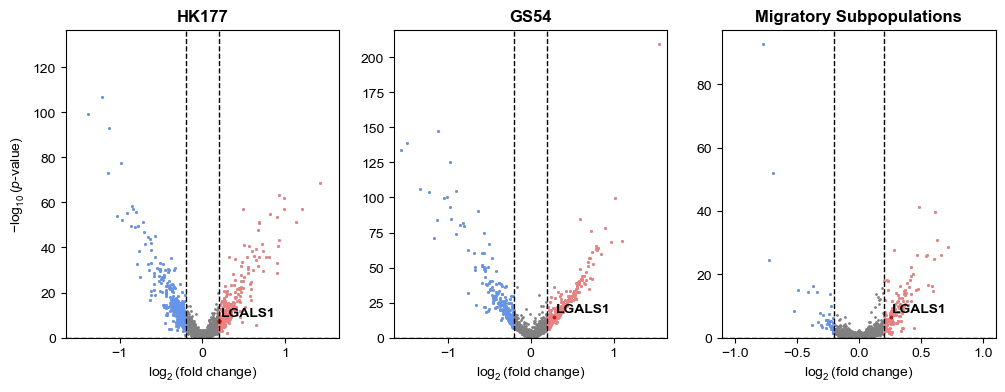

In [96]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].scatter(
    stiffmi_vs_stiffnon_hk177['coef'],
    -np.log10(stiffmi_vs_stiffnon_hk177['FDR']),
    s=1, color='grey'
)

axs[1].scatter(
    stiffmi_vs_stiffnon_gs54['coef'],
    -np.log10(stiffmi_vs_stiffnon_gs54['FDR']),
    s=1, color='grey'
)

axs[2].scatter(
    misubp_vs_nonmisubp['coef'],
    -np.log10(misubp_vs_nonmisubp['FDR']),
    s=1, color='grey'
)

axs[0].set_ylabel('$-\log_{10}(p$-value$)$')

axs[0].set_xlim(-1.5*1.1, 1.5*1.1)
axs[1].set_xlim(-1.5*1.1, 1.5*1.1)
axs[2].set_xlim(-1*1.1, 1*1.1)

for ax in axs:
    ax.set_xlabel('$\\log_2($fold change$)$')
    ax.set_ylim((0, ax.get_ylim()[1]))
    ax.vlines([-lfc_cutoff, lfc_cutoff], ax.get_ylim()[0], ax.get_ylim()[1], color='black', linestyles='--', alpha=1., linewidth=1)
    ax.hlines(p_cutoff, ax.get_xlim()[0], ax.get_xlim()[1], color='black', linestyles='--', alpha=1., linewidth=1)

axs[0].set_title('HK177', fontweight='bold')
axs[1].set_title('GS54', fontweight='bold')
axs[2].set_title('Migratory Subpopulations', fontweight='bold')

anns1 = []
anns2 = []
anns3 = []

for gene in stiffmi_vs_stiffnon_hk177.index:
    if stiffmi_vs_stiffnon_hk177.loc[gene, 'coef'] > lfc_cutoff:
        axs[0].scatter(
            stiffmi_vs_stiffnon_hk177.loc[gene, 'coef'],
            -np.log10(stiffmi_vs_stiffnon_hk177.loc[gene, 'FDR']),
            color='lightcoral', s=1
        )
    if stiffmi_vs_stiffnon_hk177.loc[gene, 'coef'] < -lfc_cutoff:
        axs[0].scatter(
            stiffmi_vs_stiffnon_hk177.loc[gene, 'coef'],
            -np.log10(stiffmi_vs_stiffnon_hk177.loc[gene, 'FDR']),
            color='cornflowerblue', s=1
        )
for gene in stiffmi_vs_stiffnon_gs54.index:
    if stiffmi_vs_stiffnon_gs54.loc[gene, 'coef'] > lfc_cutoff:
        axs[1].scatter(
            stiffmi_vs_stiffnon_gs54.loc[gene, 'coef'],
            -np.log10(stiffmi_vs_stiffnon_gs54.loc[gene, 'FDR']),
            color='lightcoral', s=1
        )
    if stiffmi_vs_stiffnon_gs54.loc[gene, 'coef'] < -lfc_cutoff:
        axs[1].scatter(
            stiffmi_vs_stiffnon_gs54.loc[gene, 'coef'],
            -np.log10(stiffmi_vs_stiffnon_gs54.loc[gene, 'FDR']),
            color='cornflowerblue', s=1
        )
for gene in misubp_vs_nonmisubp.index:
    if misubp_vs_nonmisubp.loc[gene, 'coef'] > lfc_cutoff:
        axs[2].scatter(
            misubp_vs_nonmisubp.loc[gene, 'coef'],
            -np.log10(misubp_vs_nonmisubp.loc[gene, 'FDR']),
            color='lightcoral', s=1
        )
    if misubp_vs_nonmisubp.loc[gene, 'coef'] < -lfc_cutoff:
        axs[2].scatter(
            misubp_vs_nonmisubp.loc[gene, 'coef'],
            -np.log10(misubp_vs_nonmisubp.loc[gene, 'FDR']),
            color='cornflowerblue', s=1
        )

for gene in top_vs_bottom_genes_of_intrest.index:
    axs[0].scatter(
        stiffmi_vs_stiffnon_hk177.loc[gene, 'coef'],
        -np.log10(stiffmi_vs_stiffnon_hk177.loc[gene, 'FDR']),
        color='firebrick', s=5
    )
    axs[1].scatter(
        stiffmi_vs_stiffnon_gs54.loc[gene, 'coef'],
        -np.log10(stiffmi_vs_stiffnon_gs54.loc[gene, 'FDR']),
        color='firebrick', s=3
    )
    axs[2].scatter(
        misubp_vs_nonmisubp.loc[gene, 'coef'],
        -np.log10(misubp_vs_nonmisubp.loc[gene, 'FDR']),
        color='firebrick', s=3
    )
        
    if gene == 'LGALS1':
        anns1.append(axs[0].text(
            stiffmi_vs_stiffnon_hk177.loc[gene, 'coef'],
            -np.log10(stiffmi_vs_stiffnon_hk177.loc[gene, 'FDR']),
            gene, fontweight='bold'
        ))
        anns2.append(axs[1].text(
            stiffmi_vs_stiffnon_gs54.loc[gene, 'coef'],
            -np.log10(stiffmi_vs_stiffnon_gs54.loc[gene, 'FDR']),
            gene, fontweight='bold'
        ))
        anns3.append(axs[2].text(
            misubp_vs_nonmisubp.loc[gene, 'coef'],
            -np.log10(misubp_vs_nonmisubp.loc[gene, 'FDR']),
            gene, fontweight='bold'
        ))
    else:
        anns1.append(axs[0].text(
            stiffmi_vs_stiffnon_hk177.loc[gene, 'coef'],
            -np.log10(stiffmi_vs_stiffnon_hk177.loc[gene, 'FDR']),
            gene, fontweight='regular'
        ))
        anns2.append(axs[1].text(
            stiffmi_vs_stiffnon_gs54.loc[gene, 'coef'],
            -np.log10(stiffmi_vs_stiffnon_gs54.loc[gene, 'FDR']),
            gene, fontweight='regular'
        ))
        anns3.append(axs[2].text(
            misubp_vs_nonmisubp.loc[gene, 'coef'],
            -np.log10(misubp_vs_nonmisubp.loc[gene, 'FDR']),
            gene, fontweight='regular', size = 'small'
        ))

adjust_text(anns1, arrowprops=dict(linewidth=1, color='black', alpha=0.7), ax=axs[0])
adjust_text(anns2, arrowprops=dict(linewidth=1, color='black', alpha=0.7), ax=axs[1])
adjust_text(anns3, arrowprops=dict(linewidth=1, color='black', alpha=0.7), ax=axs[2])

# Cell Type Comparison

In [97]:
p_cutoff = 0.05
upreg_only = True

In [98]:
marker_genes = pd.read_csv('MarkerGenes-combined_Neftel.csv')

## Hk177

In [99]:
HK177_marker_genes_dict = {}
for cell_type in marker_genes.columns:
    # get genes of this cell type
    HK177_genes = marker_genes[cell_type].dropna().to_numpy()
    # remove genes that aren't in our data
    HK177_genes = HK177_genes[[gene in ad_hk177.var_names for gene in HK177_genes]]
    HK177_marker_genes_dict[cell_type] = HK177_genes
    HK177_marker_genes_dict[cell_type] = np.unique(HK177_genes)
HK177_marker_genes_dict

{'MES': array(['ACTN1', 'ADM', 'AKAP12', 'ANGPTL4', 'ANXA1', 'ANXA2', 'APOE',
        'ATF3', 'BNIP3', 'BNIP3L', 'C1R', 'C1S', 'C3', 'CA9', 'CD44',
        'CDKN1A', 'CLIC1', 'CLIC4', 'CTSB', 'DDIT3', 'DNAJB9', 'EFEMP1',
        'EGLN3', 'EMP1', 'EMP3', 'ENO2', 'EPAS1', 'FN1', 'FTL', 'GBE1',
        'GDF15', 'GFPT2', 'GJA1', 'GOLT1B', 'GSN', 'HERPUD1', 'HILPDA',
        'HSPA5', 'HSPA9', 'IFITM3', 'IGFBP7', 'INSIG2', 'LDHA', 'LGALS1',
        'LGALS3', 'MGST1', 'MT1E', 'MT1X', 'MT2A', 'NAMPT', 'NDRG1',
        'NNMT', 'NPC2', 'NRN1', 'P4HA1', 'PFKP', 'PGK1', 'PLOD2', 'PLP2',
        'PPP1R15A', 'PRDX6', 'RCAN1', 'S100A10', 'S100A11', 'S100A16',
        'SERPINE1', 'SERPING1', 'SERTAD1', 'SLC2A1', 'SLC2A3', 'SLC39A14',
        'SLC6A6', 'SOD2', 'SQSTM1', 'TAGLN2', 'TIMP1', 'TNFRSF1A', 'TRAM1',
        'TRIB3', 'TUBA1C', 'UFM1', 'VIM', 'WARS', 'WWTR1', 'XPOT'],
       dtype=object),
 'AC': array(['ANXA5', 'CLU', 'CST3', 'DBI', 'F3', 'GPM6B', 'MT3', 'PMP22',
        'PON2', 'PRCP', 'RAB31

In [100]:
HK177_marker_genes_dict_sub = {subtype:np.intersect1d(HK177_marker_genes_dict[subtype], top_vs_bottom_hk177.loc[top_vs_bottom_hk177['FDR'] < 0.001].index) for subtype in HK177_marker_genes_dict.keys()}
HK177_marker_genes_dict_sub

{'MES': array(['ADM', 'AKAP12', 'ANGPTL4', 'ANXA1', 'ANXA2', 'APOE', 'ATF3',
        'BNIP3', 'BNIP3L', 'C1R', 'C1S', 'C3', 'CA9', 'CD44', 'CDKN1A',
        'CLIC1', 'CTSB', 'DDIT3', 'EFEMP1', 'EGLN3', 'EMP1', 'ENO2', 'FN1',
        'GBE1', 'GDF15', 'GFPT2', 'HILPDA', 'HSPA5', 'IFITM3', 'IGFBP7',
        'INSIG2', 'LGALS1', 'MGST1', 'MT1E', 'MT1X', 'MT2A', 'NAMPT',
        'NDRG1', 'NNMT', 'NPC2', 'NRN1', 'P4HA1', 'PFKP', 'PGK1', 'PLP2',
        'PPP1R15A', 'RCAN1', 'S100A10', 'S100A16', 'SERPINE1', 'SERPING1',
        'SERTAD1', 'SLC2A1', 'SLC2A3', 'SLC39A14', 'SLC6A6', 'TAGLN2',
        'TIMP1', 'TNFRSF1A', 'TRAM1', 'TRIB3', 'TUBA1C', 'WWTR1', 'XPOT'],
       dtype=object),
 'AC': array(['ANXA5', 'CLU', 'GPM6B', 'MT3', 'PMP22', 'PON2', 'RAB31', 'RAMP1',
        'S100A16', 'SLC1A3', 'SPARC'], dtype=object),
 'OPC': array(['ALCAM', 'APOD', 'EPB41L2', 'GPM6B', 'LIMA1', 'RAB31', 'RNF13',
        'TNS3', 'VCAN'], dtype=object),
 'NPC': array(['ATP1B1', 'BEX1', 'CEP170', 'DBN1', 'ENO2', 'E

In [101]:
cluster_obs = 'sample'

cell_type_scores = pd.DataFrame(columns=HK177_marker_genes_dict.keys(), index=ad_hk177.obs[cluster_obs].cat.categories)

for cell_type in HK177_marker_genes_dict.keys():
    sc.tl.score_genes(ad_hk177, HK177_marker_genes_dict[cell_type], score_name=cell_type, n_bins=2000)
    for cluster in ad_hk177.obs[cluster_obs].cat.categories:
        cell_type_scores.loc[cluster,cell_type] = ad_hk177.obs.loc[ad_hk177.obs[cluster_obs] == cluster, cell_type].mean()

cell_type_scores

,MES,AC,OPC,NPC
SoftMi,0.330205,-0.052623,-0.03672,-0.053532
SoftNon,0.273851,0.006036,0.014557,0.004068
StiffMi,0.309459,-0.035299,0.009503,-0.068196
StiffNon,0.026454,0.067738,0.002703,0.115821


/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 


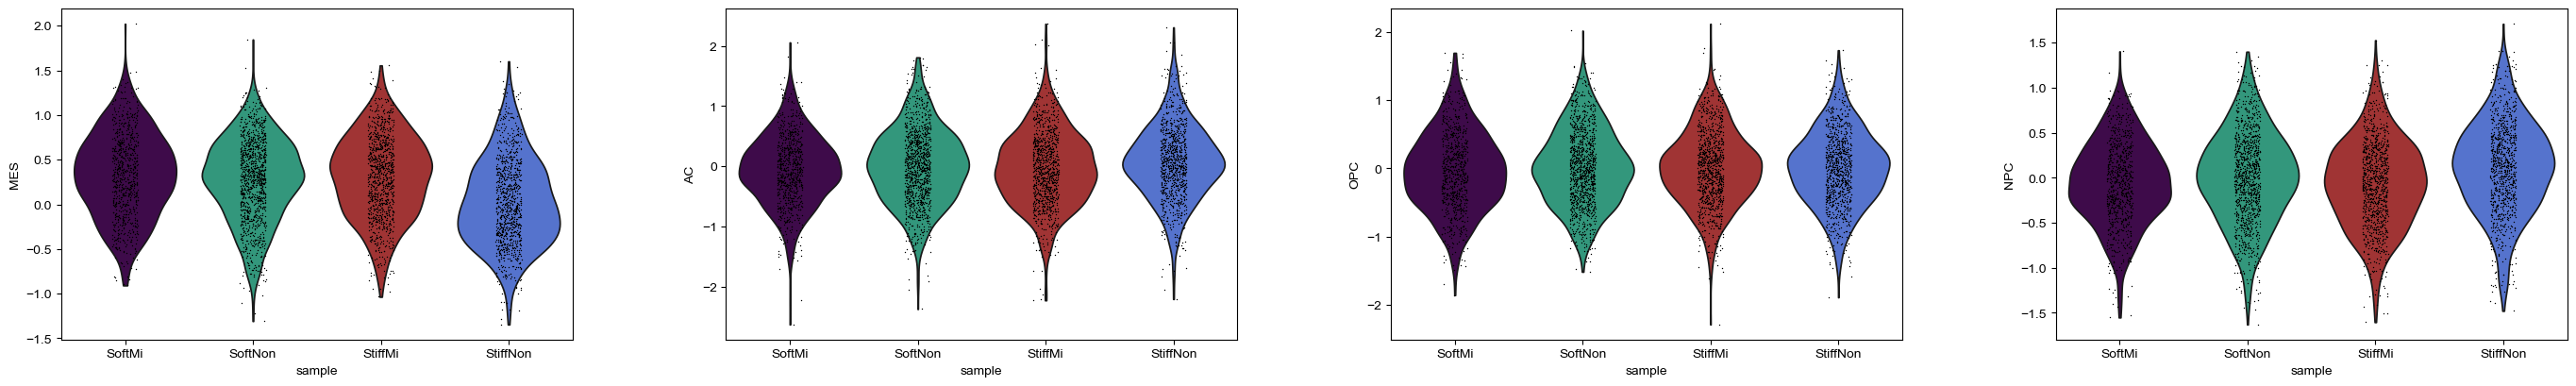

In [102]:
sc.pl.violin(ad_hk177, cell_type_scores.columns, 'sample')

categories: Soft Migratory, Soft Non-Migratory, Stiff Migratory, etc.
var_group_labels: MES, NPC


/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be igno

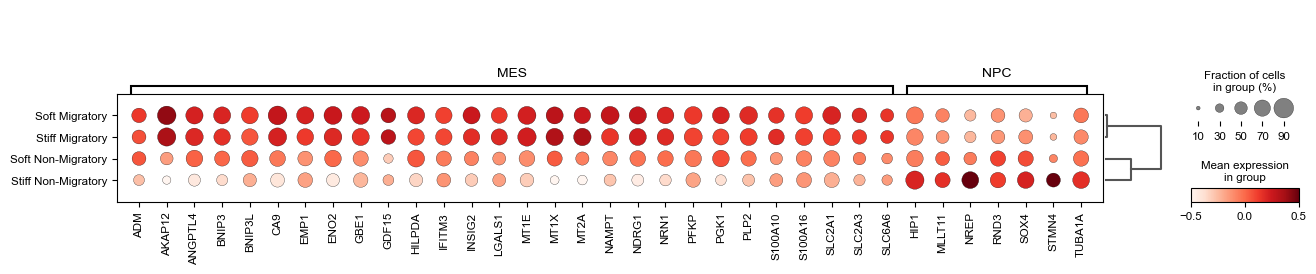

In [103]:
sc.pl.dotplot(
    sc.pp.scale(ad_hk177, copy=True),
    var_names = {
        'MES':top_vs_bottom_hk177.loc[np.isin(top_vs_bottom_hk177.index, HK177_marker_genes_dict['MES']) & (top_vs_bottom_hk177['FDR'] < 0.005) & ((top_vs_bottom_hk177['coef'] > 0.2))].index,
        'NPC':top_vs_bottom_hk177.loc[np.isin(top_vs_bottom_hk177.index, HK177_marker_genes_dict['NPC']) & (top_vs_bottom_hk177['FDR'] < 0.005) & ((top_vs_bottom_hk177['coef'] < -0.2))].index
    },
    groupby='sample_name',
    vmax=0.5, vmin=-0.5, vcenter=0,
    dendrogram=True
)

In [104]:
cell_types = np.array(['MES', 'AC', 'OPC', 'NPC'])
ad_hk177.obs['cell_type'] = cell_types[np.argmax(ad_hk177.obs[['MES', 'AC', 'OPC', 'NPC']], axis=1)]

In [105]:
# HK 177 Cell types
cluster_obs = 'sample'
HK177_sample_type_scores = pd.DataFrame(columns=HK177_marker_genes_dict.keys(), index=ad_hk177.obs[cluster_obs].cat.categories)

for cell_type in HK177_sample_type_scores.columns:
    for cluster in HK177_sample_type_scores.index:
        HK177_sample_type_scores.loc[cluster, cell_type] = np.mean(ad_hk177.obs.loc[ad_hk177.obs[cluster_obs] == cluster, 'cell_type'] == cell_type)

#sns.heatmap(sample_type_scores.astype('float'), annot=True, cmap='coolwarm')
HK177_sample_type_scores

,MES,AC,OPC,NPC
SoftMi,0.446565,0.19084,0.206107,0.156489
SoftNon,0.363955,0.211724,0.229221,0.195101
StiffMi,0.416834,0.190381,0.248497,0.144289
StiffNon,0.211268,0.266522,0.24052,0.28169


In [106]:
inner_left = 0.2   # space from figure left
inner_bottom = 0.15
inner_width = 0.65
inner_height = 0.7

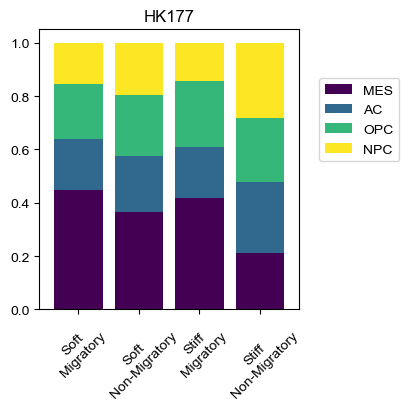

In [108]:
cell_type_cols = ['MES','AC','OPC','NPC']
ax1 = HK177_sample_type_scores[cell_type_cols].plot(
    kind='bar', 
    stacked=True, 
    figsize=(4, 4), 
    colormap='viridis', 
    width=0.8)


labels = ['Soft\nMigratory', 'Soft\nNon-Migratory' ,'Stiff\nMigratory','Stiff\nNon-Migratory']
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels, rotation=45)
ax1.set_ylabel('')
ax1.set_title('HK177')
ax1.legend(cell_type_cols, loc='best', bbox_to_anchor=(1.05, 0.85))
ax1.set_position([inner_left, inner_bottom, inner_width, inner_height])
#plt.savefig('figures/HK177_CellState.svg', bbox_inches='tight')
plt.show()


categories: SoftMi, SoftNon, StiffMi, etc.
var_group_labels: MES, AC, OPC, etc.


/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be igno

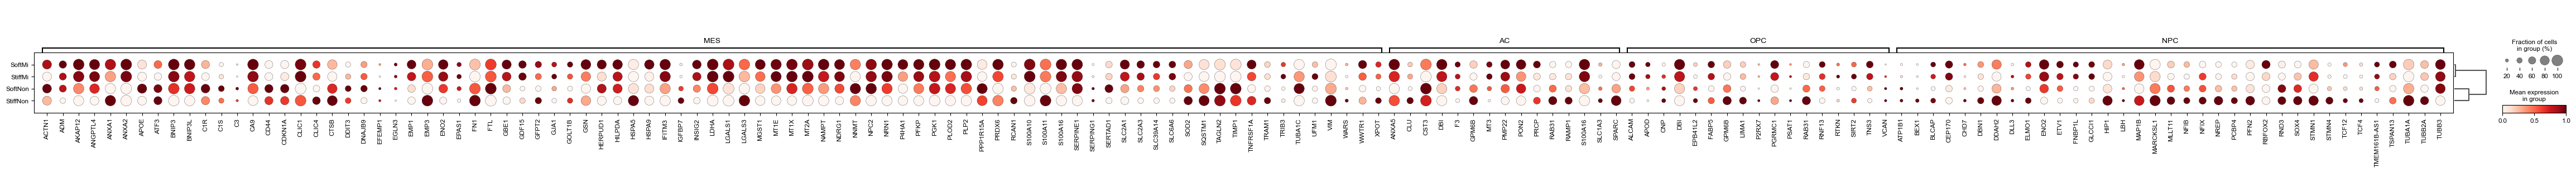

In [109]:
sc.pl.dotplot(
    ad_hk177,
    HK177_marker_genes_dict,
    groupby='sample',
    dendrogram= True,
    standard_scale='var'
)

In [110]:
HK177_marker_genes_dict_subset = {
    cell_type:HK177_marker_genes_dict[cell_type][ad_hk177[:, HK177_marker_genes_dict[cell_type]].layers['norm_counts'].mean(axis=0).A1.argsort()][:-5-1:-1] for cell_type in HK177_marker_genes_dict.keys()
}
HK177_marker_genes_dict_subset

{'MES': array(['FTL', 'VIM', 'LGALS1', 'MT2A', 'LDHA'], dtype=object),
 'AC': array(['CST3', 'ANXA5', 'S100A16', 'DBI', 'PON2'], dtype=object),
 'OPC': array(['DBI', 'PGRMC1', 'GPM6B', 'RAB31', 'FABP5'], dtype=object),
 'NPC': array(['TUBA1A', 'MARCKSL1', 'MAP1B', 'TUBB3', 'STMN1'], dtype=object)}

/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be igno

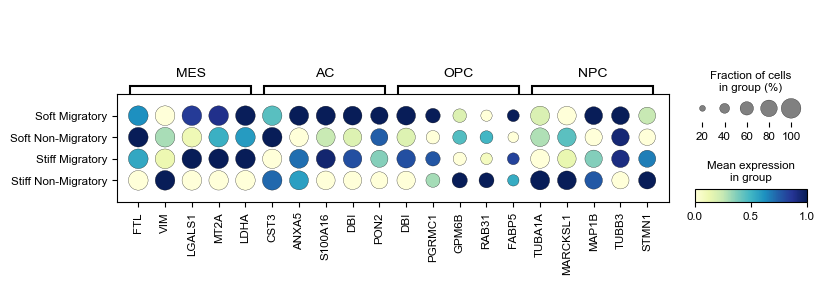

In [ ]:
sc.pl.dotplot(
    ad_hk177,
    HK177_marker_genes_dict_subset,
    groupby='sample_name',
    dendrogram= False,
    standard_scale='var',
    cmap= 'YlGnBu',
    #save = 'HK177_marker_genes_dotplot.svg'
)


## GS54

In [112]:
GS54_marker_genes_dict = {}
for cell_type in marker_genes.columns:
    # get genes of this cell type
    GS54_genes = marker_genes[cell_type].dropna().to_numpy()
    # remove genes that aren't in our data
    GS54_genes = GS54_genes[[gene in ad_gs54.var_names for gene in GS54_genes]]
    GS54_marker_genes_dict[cell_type] = GS54_genes
    GS54_marker_genes_dict[cell_type] = np.unique(GS54_genes)
GS54_marker_genes_dict

{'MES': array(['ATF3', 'BNIP3', 'BNIP3L', 'CLIC1', 'DDIT3', 'EGLN3', 'EMP1',
        'ENO2', 'FTL', 'HERPUD1', 'HSPA5', 'HSPA9', 'LDHA', 'LGALS1',
        'NAMPT', 'P4HA1', 'PGK1', 'PLOD2', 'PRDX6', 'RPL21', 'S100A10',
        'SOD2', 'TRAM1', 'TUBA1C', 'VIM', 'XPOT'], dtype=object),
 'AC': array(['ATP1A2', 'GPM6B', 'MT3', 'PMP22', 'PTPRZ1', 'S100B', 'SPARC',
        'TSPAN7'], dtype=object),
 'OPC': array(['ALCAM', 'BCAS1', 'CADM2', 'CNP', 'CNTN1', 'GPM6B', 'LHFPL3',
        'PGRMC1', 'PHYHIPL', 'PLP1', 'PTPRZ1', 'RNF13', 'SCRG1', 'SIRT2',
        'TNR', 'VCAN'], dtype=object),
 'NPC': array(['ABAT', 'ASCL1', 'ATP1B1', 'BTG2', 'CEP170', 'CHD7', 'DDAH2',
        'ENO2', 'ETV1', 'FNBP1L', 'GLCCI1', 'HIP1', 'KIF5C', 'LBH',
        'MAP1B', 'MAP2', 'MARCKSL1', 'NFIB', 'NFIX', 'PFN2', 'PTPRS',
        'RBFOX2', 'RND3', 'SOX11', 'SOX4', 'STMN1', 'TCF12', 'TCF4',
        'TMEM161B-AS1', 'TNR', 'TUBA1A', 'TUBB2A'], dtype=object)}

In [113]:
#ad_gs54.X = ad_gs54.layers['cc_regressed'].copy()

cluster_obs = 'sample'

gs54_cell_type_scores = pd.DataFrame(columns=GS54_marker_genes_dict.keys(), index=ad_gs54.obs[cluster_obs].cat.categories)

for cell_type in GS54_marker_genes_dict.keys():
    sc.tl.score_genes(ad_gs54, GS54_marker_genes_dict[cell_type], score_name=cell_type, n_bins=2000)
    for cluster in ad_gs54.obs[cluster_obs].cat.categories:
        gs54_cell_type_scores.loc[cluster,cell_type] = ad_gs54.obs.loc[ad_gs54.obs[cluster_obs] == cluster, cell_type].mean()

#ad_gs54.X = ad_gs54.layers['norm_counts'].copy()
gs54_cell_type_scores

,MES,AC,OPC,NPC
SoftMi,-0.024236,-0.092484,-0.011449,-0.020349
SoftNon,-0.012201,0.084547,0.004846,0.043176
StiffMi,-0.008783,-0.069281,-0.016146,-0.006756
StiffNon,0.068788,0.116141,0.030916,-0.021536


In [114]:
cell_types = np.array(['MES', 'AC', 'OPC', 'NPC'])
ad_gs54.obs['cell_type'] = cell_types[np.argmax(ad_gs54.obs[['MES', 'AC', 'OPC', 'NPC']], axis=1)]


In [115]:
# GS54 Cell types
cluster_obs = 'sample'
gs54_cell_type_scores = pd.DataFrame(columns=GS54_marker_genes_dict.keys(), index=ad_gs54.obs[cluster_obs].cat.categories)

for cell_type in gs54_cell_type_scores.columns:
    for cluster in gs54_cell_type_scores.index:
        gs54_cell_type_scores.loc[cluster, cell_type] = np.mean(ad_gs54.obs.loc[ad_gs54.obs[cluster_obs] == cluster, 'cell_type'] == cell_type)

#sns.heatmap(sample_type_scores.astype('float'), annot=True, cmap='coolwarm')
gs54_cell_type_scores

,MES,AC,OPC,NPC
SoftMi,0.286373,0.207373,0.269256,0.236998
SoftNon,0.196093,0.410218,0.156273,0.237415
StiffMi,0.276577,0.25497,0.221262,0.247191
StiffNon,0.273504,0.426282,0.183761,0.116453


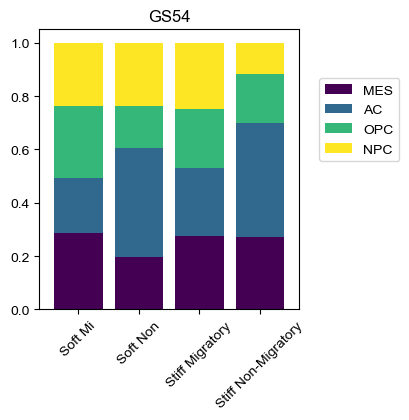

In [116]:
cell_type_cols = ['MES','AC','OPC','NPC']
ax1 = gs54_cell_type_scores[cell_type_cols].plot(
    kind='bar', 
    stacked=True, 
    figsize=(4, 4), 
    colormap='viridis', 
    width=0.8)


labels = ['Soft Mi', 'Soft Non' ,'Stiff Migratory','Stiff Non-Migratory']
#labels = ['Migratory','Non-Migratory']
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels, rotation=45)
ax1.set_ylabel('')
ax1.set_title('GS54')
ax1.legend(cell_type_cols, loc='best', bbox_to_anchor=(1.05, 0.85))
ax1.set_position([inner_left, inner_bottom, inner_width, inner_height])
#plt.savefig('Figures/GS54_CellState.svg', bbox_inches='tight')
plt.show()


categories: SoftMi, SoftNon, StiffMi, etc.
var_group_labels: MES, AC, OPC, etc.


/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be igno

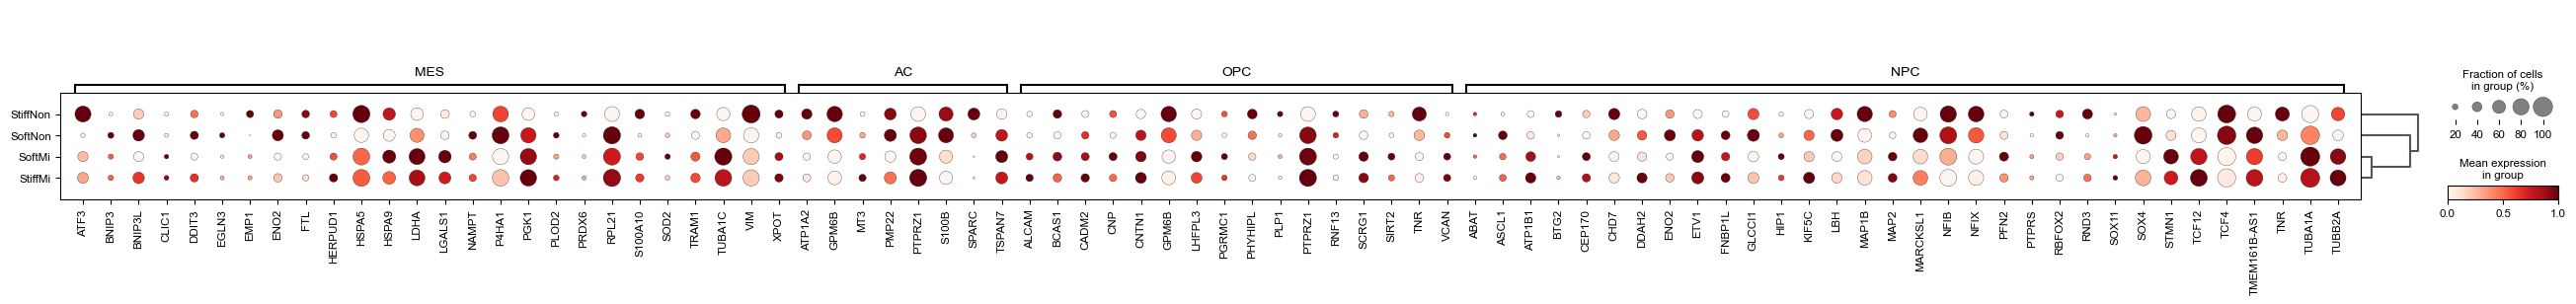

In [117]:
sc.pl.dotplot(
    ad_gs54,
    GS54_marker_genes_dict,
    groupby='sample',
    dendrogram= True,
    standard_scale='var'
)

In [118]:
GS54_marker_genes_dict_subset = {
    cell_type:GS54_marker_genes_dict[cell_type][ad_gs54[:, GS54_marker_genes_dict[cell_type]].layers['norm_counts'].mean(axis=0).A1.argsort()][:-5-1:-1] for cell_type in GS54_marker_genes_dict.keys()
}
GS54_marker_genes_dict_subset

{'MES': array(['VIM', 'RPL21', 'HSPA5', 'TUBA1C', 'P4HA1'], dtype=object),
 'AC': array(['PTPRZ1', 'GPM6B', 'S100B', 'PMP22', 'TSPAN7'], dtype=object),
 'OPC': array(['PTPRZ1', 'GPM6B', 'TNR', 'CNTN1', 'LHFPL3'], dtype=object),
 'NPC': array(['TUBA1A', 'TCF4', 'NFIB', 'SOX4', 'TMEM161B-AS1'], dtype=object)}

/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be igno

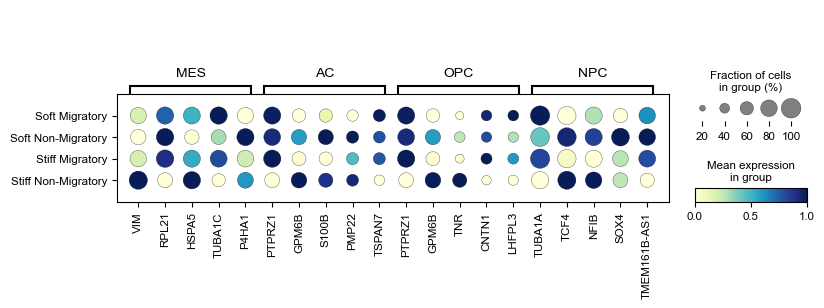

In [ ]:
sc.pl.dotplot(
    ad_gs54,
    GS54_marker_genes_dict_subset,
    groupby='sample_name',
    dendrogram= False,
    standard_scale='var',
    cmap='YlGnBu', #'viridis',
    #save = 'GS54_marker_genes_dotplot.svg'
)
#plt.savefig('figures/GS54_marker_genes_dotplot.svg', bbox_inches='tight')

## HK177 Lins

In [120]:
ad_hk177_sub.layers

LayersView with keys: norm_counts, raw_counts, cc_regressed

/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


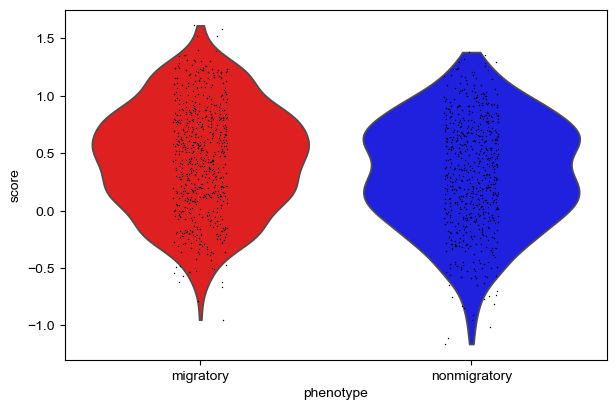

In [121]:
sc.pl.violin(
    sc.tl.score_genes(
        ad_hk177_sub[(ad_hk177_sub.obs['phenotype'] != '')], 
        HK177_marker_genes_dict['MES'], 
        n_bins=1000, copy=True
    ),
    keys='score',
    groupby='phenotype'
)


/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


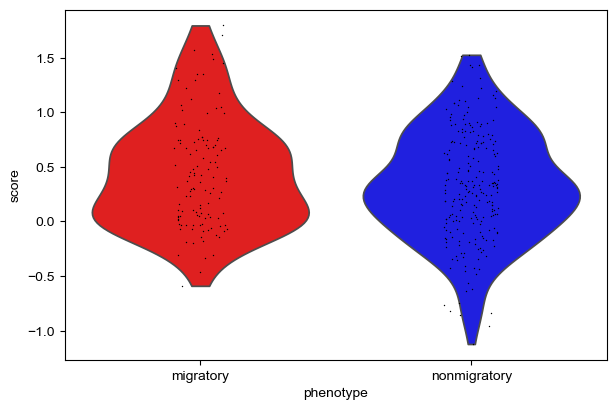

In [122]:
sc.pl.violin(
    sc.tl.score_genes(
        ad_hk177_sub[(ad_hk177_sub.obs['sample']=='StiffNon') & (ad_hk177_sub.obs['phenotype'] != '')], 
        HK177_marker_genes_dict['MES'], 
        n_bins=1000, copy=True
    ),
    keys='score',
    groupby='phenotype'
)


/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


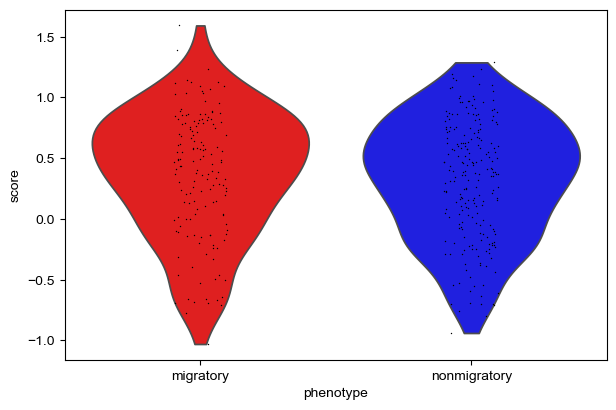

In [123]:
sc.pl.violin(
    sc.tl.score_genes(
        ad_hk177_sub[(ad_hk177_sub.obs['sample']=='SoftNon') & (ad_hk177_sub.obs['phenotype'] != '')], 
        HK177_marker_genes_dict['MES'], 
        n_bins=1000, copy=True
    ),
    keys='score',
    groupby='phenotype'
)


/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


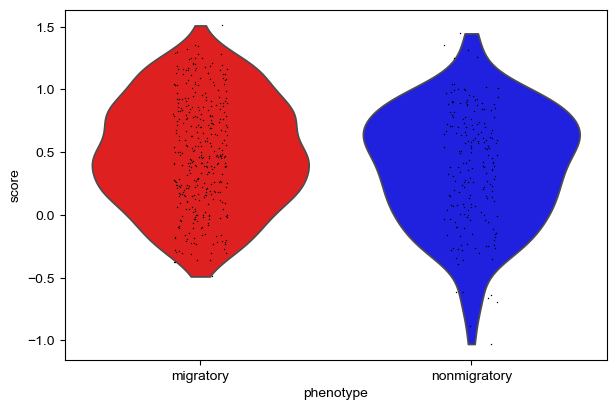

In [124]:
sc.pl.violin(
    sc.tl.score_genes(
        ad_hk177_sub[(ad_hk177_sub.obs['gel_side']=='bottom') & (ad_hk177_sub.obs['phenotype'] != '')], 
        HK177_marker_genes_dict['MES'], 
        n_bins=1000, copy=True
    ),
    keys='score',
    groupby='phenotype'
)

/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


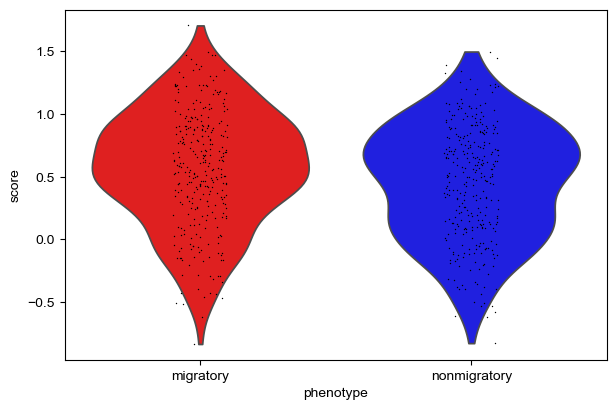

In [125]:
sc.pl.violin(
    sc.tl.score_genes(
        ad_hk177_sub[(ad_hk177_sub.obs['substrate']=='soft') & (ad_hk177_sub.obs['phenotype'] != '')], 
        HK177_marker_genes_dict['MES'], 
        n_bins=1000, copy=True
    ),
    keys='score',
    groupby='phenotype'
)

/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


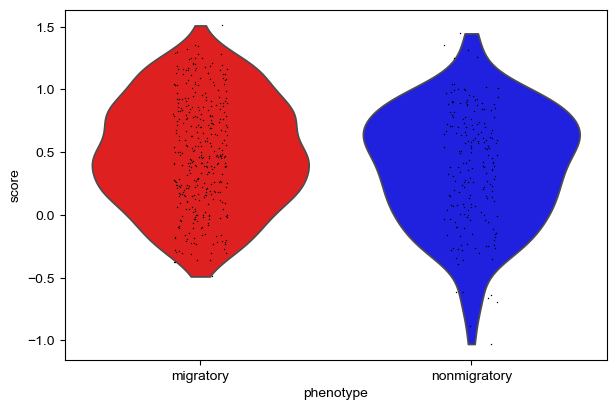

In [126]:
sc.pl.violin(
    sc.tl.score_genes(
        ad_hk177_sub[(ad_hk177_sub.obs['gel_side']=='bottom') & (ad_hk177_sub.obs['phenotype'] != '')], 
        HK177_marker_genes_dict['MES'], 
        n_bins=1000, copy=True
    ),
    keys='score',
    groupby='phenotype'
)

/tmp/ipykernel_491669/2191738548.py:45: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


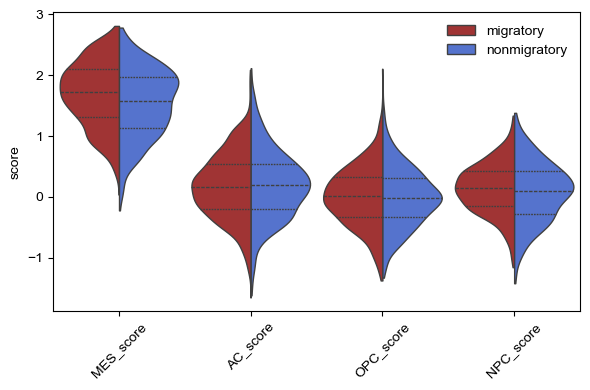

In [127]:
adata = ad_hk177_sub[(ad_hk177_sub.obs['phenotype'] != '')].copy()

score_cols =['MES_score', 'AC_score','OPC_score' ,'NPC_score']

# score genes
sc.tl.score_genes(
    adata,
    HK177_marker_genes_dict['MES'],
    score_name='MES_score',
    n_bins=100
)

sc.tl.score_genes(
    adata,
    HK177_marker_genes_dict['AC'],
    score_name='AC_score',
    n_bins=100
)

sc.tl.score_genes(
    adata,
    HK177_marker_genes_dict['OPC'],
    score_name='OPC_score',
    n_bins=100
)

sc.tl.score_genes(
    adata,
    HK177_marker_genes_dict['NPC'],
    score_name='NPC_score',
    n_bins=100
)

# extract plotting dataframe
df = adata.obs[['phenotype'] + score_cols].copy()

df_long = df.melt(
    id_vars='phenotype',
    value_vars=score_cols,
    var_name='score_type',
    value_name='score'
)

fig, ax = plt.subplots(figsize=(6,4))
ax = sns.violinplot(
    data=df_long,
    x='score_type',
    y='score',
    hue='phenotype',
    split=True,
    inner='quart', #['box', 'quart', 'stick', 'point', None]
    cut=0,
    width=0.9,
    scale='width',
    linewidth=1,
    palette={'migratory': 'firebrick', 'nonmigratory': 'royalblue'},
    orient="v", 
)

plt.xticks(rotation=45)
plt.xlabel('')
plt.legend(title='', frameon=False)
plt.tight_layout()
plt.show()

In [141]:
ad_hk177_sub.X = ad_hk177_sub.layers['cc_regressed'].copy()
cluster_obs = 'phenotype'

phenotype_cell_type_scores = pd.DataFrame(columns=HK177_marker_genes_dict.keys(), index=ad_hk177_sub.obs[cluster_obs].cat.categories)

for cell_type in HK177_marker_genes_dict.keys():
    sc.tl.score_genes(ad_hk177_sub, HK177_marker_genes_dict[cell_type], score_name=cell_type)
    for cluster in ad_hk177_sub.obs[cluster_obs].cat.categories:
        phenotype_cell_type_scores.loc[cluster,cell_type] = ad_hk177_sub.obs.loc[ad_hk177_sub.obs[cluster_obs] == cluster, cell_type].mean()

ad_hk177_sub.X = ad_hk177_sub.layers['norm_counts'].copy()
phenotype_cell_type_scores

,MES,AC,OPC,NPC
,0.05322,0.035825,-0.005708,0.006111
migratory,0.008149,-0.027688,0.034556,0.030932
nonmigratory,-0.147805,-0.012612,0.02601,-0.018809


In [142]:
cell_types = np.array(['MES', 'AC', 'OPC', 'NPC'])
ad_hk177_sub.obs['cell_type'] = cell_types[np.argmax(ad_hk177_sub.obs[['MES', 'AC', 'OPC', 'NPC']], axis=1)]


In [143]:
# HK 177 Cell types
cluster_obs = 'phenotype'
phenotype_cell_type_scores = pd.DataFrame(columns=HK177_marker_genes_dict.keys(), index=ad_hk177_sub.obs[cluster_obs].cat.categories)

for cell_type in phenotype_cell_type_scores.columns:
    for cluster in phenotype_cell_type_scores.index:
        phenotype_cell_type_scores.loc[cluster, cell_type] = np.mean(ad_hk177_sub.obs.loc[ad_hk177_sub.obs[cluster_obs] == cluster, 'cell_type'] == cell_type)

#sns.heatmap(sample_type_scores.astype('float'), annot=True, cmap='coolwarm')
phenotype_cell_type_scores 

,MES,AC,OPC,NPC
,0.281948,0.249284,0.24298,0.225788
migratory,0.24961,0.204368,0.310452,0.235569
nonmigratory,0.175573,0.268702,0.317557,0.238168


In [144]:
phenotype_cell_type_scores = phenotype_cell_type_scores[phenotype_cell_type_scores.index != '']

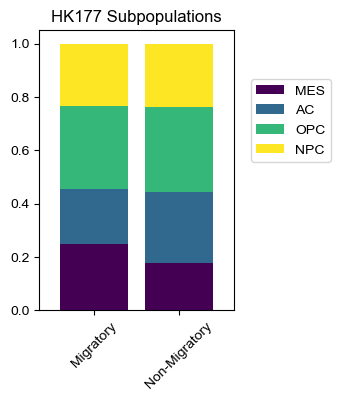

In [145]:
cell_type_cols = ['MES','AC','OPC','NPC']
ax1 = phenotype_cell_type_scores[cell_type_cols].plot(
    kind='bar', 
    stacked=True, 
    figsize=(3, 4), 
    colormap='viridis', 
    width=0.8)


labels = ['Migratory','Non-Migratory']
#labels = ['Migratory','Non-Migratory']
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels, rotation=45)
ax1.set_ylabel('')
ax1.set_title('HK177 Subpopulations')
ax1.legend(cell_type_cols, loc='best', bbox_to_anchor=(1.05, 0.85))
ax1.set_position([inner_left, inner_bottom, inner_width, inner_height])
#plt.savefig('figures/hk177_subpop_cellsubtype.svg', bbox_inches='tight')
plt.show()

In [146]:
phenotype_marker_genes_dict_subset = {
    cell_type:HK177_marker_genes_dict[cell_type][ad_hk177_sub[:, HK177_marker_genes_dict[cell_type]].layers['norm_counts'].mean(axis=0).A1.argsort()][:-5-1:-1] for cell_type in HK177_marker_genes_dict.keys()
}
phenotype_marker_genes_dict_subset

{'MES': array(['FTL', 'VIM', 'LGALS1', 'MT2A', 'LDHA'], dtype=object),
 'AC': array(['CST3', 'ANXA5', 'S100A16', 'DBI', 'PON2'], dtype=object),
 'OPC': array(['DBI', 'PGRMC1', 'GPM6B', 'RAB31', 'FABP5'], dtype=object),
 'NPC': array(['TUBA1A', 'MARCKSL1', 'TUBB3', 'MAP1B', 'STMN1'], dtype=object)}

/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be igno

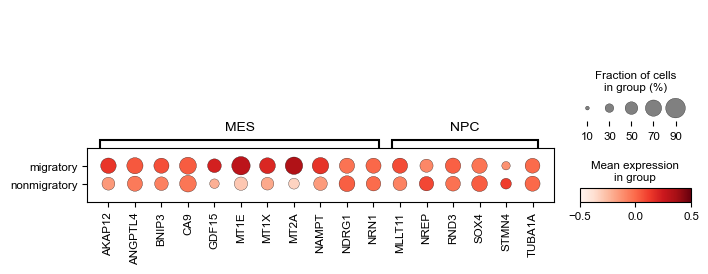

In [147]:
sc.pl.dotplot(
    sc.pp.scale(ad_hk177_sub[ad_hk177_sub.obs['phenotype']!=''], copy=True),
    var_names = {
        'MES':top_vs_bottom_hk177.loc[np.isin(top_vs_bottom_hk177.index, HK177_marker_genes_dict['MES']) & (top_vs_bottom_hk177['FDR'] < 0.005) & ((top_vs_bottom_hk177['coef'] > 0.5))].index,
        'NPC':top_vs_bottom_hk177.loc[np.isin(top_vs_bottom_hk177.index, HK177_marker_genes_dict['NPC']) & (top_vs_bottom_hk177['FDR'] < 0.005) & ((top_vs_bottom_hk177['coef'] < -0.25))].index
    },
    groupby='phenotype',
    vmax=0.5, vmin=-0.5, vcenter=0,
    dendrogram=True
)

/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be igno

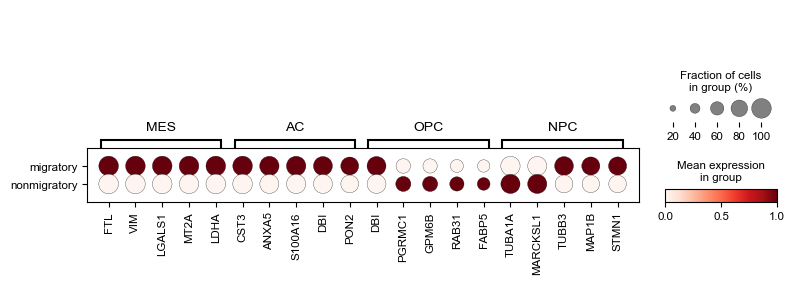

In [148]:
sc.pl.dotplot(
    ad_hk177_sub[ad_hk177_sub.obs['phenotype']!=''],
    phenotype_marker_genes_dict_subset,
    groupby='phenotype',
    dendrogram= True,
    standard_scale='var'
)

# Stem Markers

## HK177

GBM Stem marker from doi: 10.3390/cells9051236 

In [ ]:
stem_markers = ['PROM1', 'CD44', 'FUT4', 'CD70', 'S100A4', 'ALDH1A3', 'Nanog', 'POU5F1', 'SOX2', 'NES']
sample_column = 'StiffMi'

Mi_stem_results = []

for sample in ad_hk177.obs['sample'].unique():
    adata_sample = ad_hk177[ad_hk177.obs['sample'] == sample]
    for gene in stem_markers:
        if gene in ad_hk177.var_names:
            gene_idx = ad_hk177.var_names.get_loc(gene)
            gene_expr = adata_sample.layers['norm_counts'][:, gene_idx]
            
            # Convert to dense if sparse
            if not isinstance(gene_expr, np.ndarray):
                gene_expr = gene_expr.toarray().flatten()
            
            total_log1p = gene_expr.sum()
            all_genes_expr = adata_sample.layers['norm_counts']
            if not isinstance(all_genes_expr, np.ndarray):
                all_genes_expr = all_genes_expr.toarray()
            denom = all_genes_expr.sum()

            total_log1p = total_log1p 
            
            Mi_stem_results.append({
                'sample': sample,
                'gene': gene,
                'total_log1p' : total_log1p
            })
        else:
            print(f"Gene {gene} not found in var_names.")

hk177_mi_stem_df = pd.DataFrame(Mi_stem_results)
hk177_mi_stem_df


Gene PROM1 not found in var_names.
Gene FUT4 not found in var_names.
Gene CD70 not found in var_names.
Gene ALDH1A3 not found in var_names.
Gene Nanog not found in var_names.
Gene POU5F1 not found in var_names.
Gene SOX2 not found in var_names.
Gene PROM1 not found in var_names.
Gene FUT4 not found in var_names.
Gene CD70 not found in var_names.
Gene ALDH1A3 not found in var_names.
Gene Nanog not found in var_names.
Gene POU5F1 not found in var_names.
Gene SOX2 not found in var_names.
Gene PROM1 not found in var_names.
Gene FUT4 not found in var_names.
Gene CD70 not found in var_names.
Gene ALDH1A3 not found in var_names.
Gene Nanog not found in var_names.
Gene POU5F1 not found in var_names.
Gene SOX2 not found in var_names.
Gene PROM1 not found in var_names.
Gene FUT4 not found in var_names.
Gene CD70 not found in var_names.
Gene ALDH1A3 not found in var_names.
Gene Nanog not found in var_names.
Gene POU5F1 not found in var_names.
Gene SOX2 not found in var_names.


,sample,gene,total_log1p
0,SoftMi,CD44,2703.543457
1,SoftMi,S100A4,6202.836914
2,SoftMi,NES,2115.307617
3,SoftNon,CD44,4323.490723
4,SoftNon,S100A4,8813.544922
5,SoftNon,NES,2790.632324
6,StiffMi,CD44,3431.345947
7,StiffMi,S100A4,7900.200195
8,StiffMi,NES,2630.660645
9,StiffNon,CD44,3380.901855


/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 


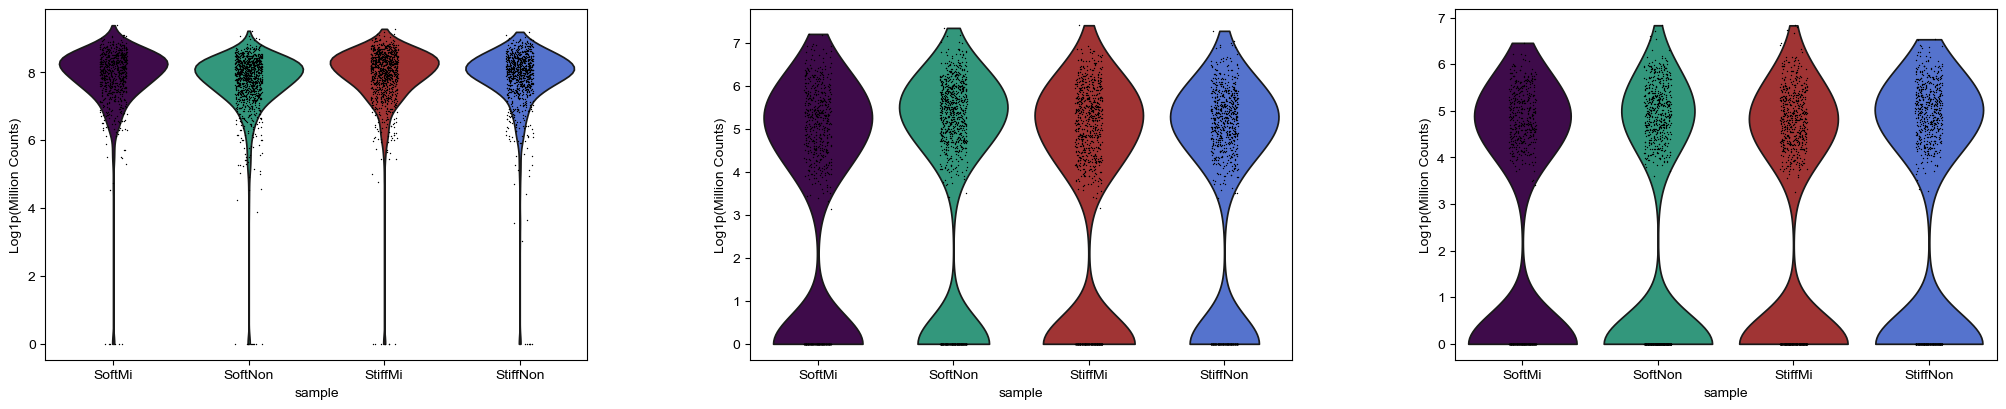

In [150]:
sc.pl.violin(ad_hk177, keys=['S100A4', 'CD44', 'NES'], 
    groupby='sample', split=False, 
    multi_panel=False, 
    palette = ['#440154ff','#22a884ff','#b22222','#4169e1'],
    ylabel='Log1p(Million Counts)',
    layer='norm_counts'
)

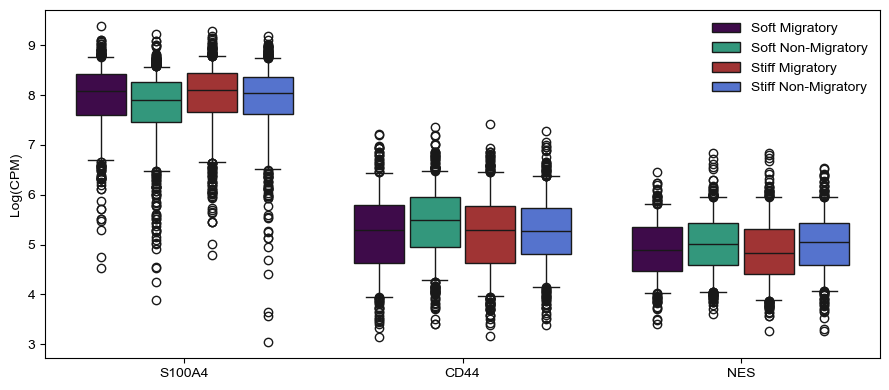

In [ ]:
genes = ['S100A4', 'CD44', 'NES'] 
sample_column = 'sample_name'  

df_list = []
for sample in ad_hk177.obs[sample_column].unique():
    for gene in genes:
        mask = ad_hk177.obs[sample_column] == sample
        expr = ad_hk177[mask, gene].layers['norm_counts'].toarray().flatten()
        expr_nonzero = expr[expr > 0]
        
        for val in expr_nonzero:
            df_list.append({'Sample': sample, 'Gene': gene, 'Expression': val})

df = pd.DataFrame(df_list)

plt.figure(figsize=(9, 4))

sns.boxplot(data=df,
            x='Gene',
            y='Expression',
            hue='Sample',
            palette=['#440154ff','#22a884ff','#b22222','#4169e1'],
            gap=0.1,
            fill=True,
            whis=[5,95],
            legend= True)

plt.xticks(rotation=0)
plt.legend(frameon=False)
plt.xlabel('')
plt.ylabel('Log(CPM)')
plt.tight_layout()
plt.savefig('figures/HK177_stem_markers_wLegend.svg')
plt.show()

## GS54

In [ ]:
stem_markers = ['PROM1', 'CD44', 'FUT4', 'CD70', 'S100A4', 'ALDH1A3', 'Nanog', 'POU5F1', 'SOX2', 'NES']
sample_column = 'StiffMi'

Mi_stem_results = []

for sample in ad_gs54.obs['sample'].unique():
    adata_sample = ad_gs54[ad_gs54.obs['sample'] == sample]
    for gene in stem_markers:
        if gene in ad_gs54.var_names:
            gene_idx = ad_gs54.var_names.get_loc(gene)
            gene_expr = adata_sample.layers['norm_counts'][:, gene_idx]
            
            if not isinstance(gene_expr, np.ndarray):
                gene_expr = gene_expr.toarray().flatten()
            
            total_log1p = gene_expr.sum()
            
            all_genes_expr = adata_sample.layers['norm_counts']
            if not isinstance(all_genes_expr, np.ndarray):
                all_genes_expr = all_genes_expr.toarray()
            denom = all_genes_expr.sum()

            total_log1p = total_log1p 
            
            Mi_stem_results.append({
                'sample': sample,
                'gene': gene,
                'total_log1p' : total_log1p
            })
        else:
            print(f"Gene {gene} not found in var_names.")

GS54_mi_stem_df = pd.DataFrame(Mi_stem_results)
GS54_mi_stem_df


Gene PROM1 not found in var_names.
Gene CD44 not found in var_names.
Gene FUT4 not found in var_names.
Gene CD70 not found in var_names.
Gene S100A4 not found in var_names.
Gene ALDH1A3 not found in var_names.
Gene Nanog not found in var_names.
Gene POU5F1 not found in var_names.
Gene NES not found in var_names.
Gene PROM1 not found in var_names.
Gene CD44 not found in var_names.
Gene FUT4 not found in var_names.
Gene CD70 not found in var_names.
Gene S100A4 not found in var_names.
Gene ALDH1A3 not found in var_names.
Gene Nanog not found in var_names.
Gene POU5F1 not found in var_names.
Gene NES not found in var_names.
Gene PROM1 not found in var_names.
Gene CD44 not found in var_names.
Gene FUT4 not found in var_names.
Gene CD70 not found in var_names.
Gene S100A4 not found in var_names.
Gene ALDH1A3 not found in var_names.
Gene Nanog not found in var_names.
Gene POU5F1 not found in var_names.
Gene NES not found in var_names.
Gene PROM1 not found in var_names.
Gene CD44 not found in 

,sample,gene,total_log1p
0,SoftMi,SOX2,1777.700684
1,SoftNon,SOX2,1748.591797
2,StiffMi,SOX2,1380.661621
3,StiffNon,SOX2,771.945801


/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


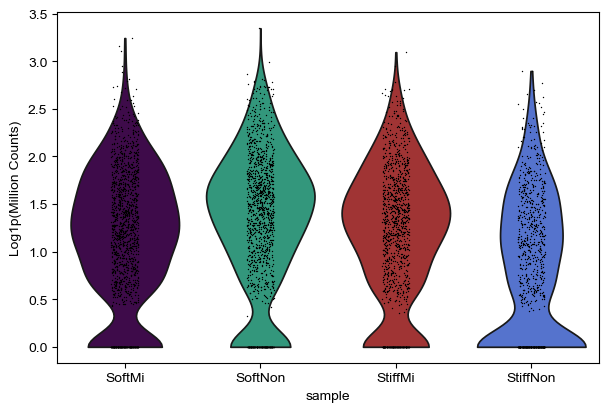

In [153]:
sc.pl.violin(ad_gs54,
             keys=['SOX2'], 
             groupby='sample', split=False, 
             multi_panel=False, 
             ylabel='Log1p(Million Counts)', layer='norm_counts')

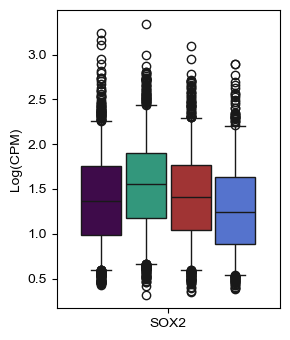

In [ ]:
genes = ['SOX2'] 
sample_column = 'sample_name'  

df_list = []
for sample in ad_gs54.obs[sample_column].unique():
    for gene in genes:
        mask = ad_gs54.obs[sample_column] == sample
        expr = ad_gs54[mask, gene].layers['norm_counts'].toarray().flatten()
        expr_nonzero = expr[expr > 0]
        
        for val in expr_nonzero:
            df_list.append({'Sample': sample, 'Gene': gene, 'Expression': val})

df = pd.DataFrame(df_list)

plt.figure(figsize=(3, 3.5))

sns.boxplot(data=df,
            x='Gene',
            y='Expression',
            hue='Sample',
            palette=['#440154ff','#22a884ff','#b22222','#4169e1'],
            gap=0.1,
            fill=True,
            whis=[5,95],
            legend= False)

plt.xticks(rotation=0)
plt.xlabel('')
plt.ylabel('Log(CPM)')
plt.tight_layout()
plt.savefig('figures/GS54_stem_markers.svg')
plt.show()

## Subpop lineages

In [155]:
stem_markers = ['PROM1', 'CD44', 'FUT4', 'CD70', 'S100A4', 'ALDH1A3', 'Nanog', 'POU5F1', 'SOX2', 'NES']
sample_column = 'migratory'

Mi_stem_results = []

for sample in ad_hk177_sub.obs['phenotype'].unique():
    adata_sample = ad_hk177_sub[ad_hk177_sub.obs['phenotype'] == sample]
    for gene in stem_markers:
        if gene in ad_hk177_sub.var_names:
            gene_idx = ad_hk177_sub.var_names.get_loc(gene)

            gene_expr = adata_sample.layers['norm_counts'][:, gene_idx]

            if not isinstance(gene_expr, np.ndarray):
                gene_expr = gene_expr.toarray().flatten()
            
            total_log1p = gene_expr.sum()
            
            all_genes_expr = adata_sample.layers['norm_counts']
            if not isinstance(all_genes_expr, np.ndarray):
                all_genes_expr = all_genes_expr.toarray()
            denom = all_genes_expr.sum()

            total_log1p = total_log1p 
            
            Mi_stem_results.append({
                'sample': sample,
                'gene': gene,
                'total_log1p' : total_log1p
            })
        else:
            print(f"Gene {gene} not found in var_names.")

ad_hk177_sub_df = pd.DataFrame(Mi_stem_results)
ad_hk177_sub_df


Gene PROM1 not found in var_names.
Gene FUT4 not found in var_names.
Gene CD70 not found in var_names.
Gene ALDH1A3 not found in var_names.
Gene Nanog not found in var_names.
Gene POU5F1 not found in var_names.
Gene SOX2 not found in var_names.
Gene PROM1 not found in var_names.
Gene FUT4 not found in var_names.
Gene CD70 not found in var_names.
Gene ALDH1A3 not found in var_names.
Gene Nanog not found in var_names.
Gene POU5F1 not found in var_names.
Gene SOX2 not found in var_names.
Gene PROM1 not found in var_names.
Gene FUT4 not found in var_names.
Gene CD70 not found in var_names.
Gene ALDH1A3 not found in var_names.
Gene Nanog not found in var_names.
Gene POU5F1 not found in var_names.
Gene SOX2 not found in var_names.


,sample,gene,total_log1p
0,,CD44,6470.285156
1,,S100A4,13805.513672
2,,NES,4525.547852
3,migratory,CD44,2171.974121
4,migratory,S100A4,5113.800781
5,migratory,NES,1894.903931
6,nonmigratory,CD44,2514.365723
7,nonmigratory,S100A4,5037.871582
8,nonmigratory,NES,2007.912720


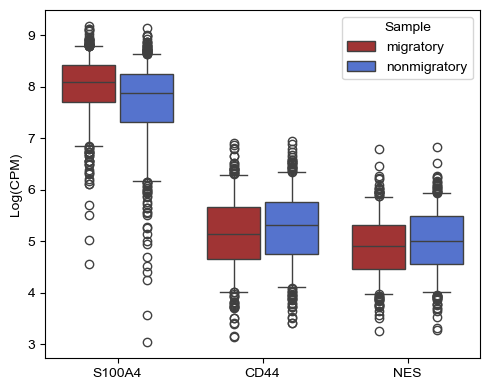

In [ ]:
genes = ['S100A4', 'CD44', 'NES'] 
sample_column = 'phenotype'  

df_list = []
for sample in ad_hk177_sub[ad_hk177_sub.obs['phenotype']!=''].obs[sample_column].unique():
    for gene in genes:
        mask = ad_hk177_sub.obs[sample_column] == sample
        expr = ad_hk177_sub[mask, gene].layers['norm_counts'].toarray().flatten()
        expr_nonzero = expr[expr > 0]
        
        for val in expr_nonzero:
            df_list.append({'Sample': sample, 'Gene': gene, 'Expression': val})

df = pd.DataFrame(df_list)

# Plot
plt.figure(figsize=(5, 4))

sns.boxplot(data=df,
            x='Gene',
            y='Expression',
            hue='Sample',
            palette=['#b22222','#4169e1'],
            gap=0.1,
            fill=True,
            whis=[5,95],
            legend= True)

plt.xticks(rotation=0)
plt.xlabel('')
plt.ylabel('Log(CPM)')
plt.tight_layout()
#plt.savefig('figures/HK177_subpops_stem_markers_wLegend.svg')
plt.show()